## Telco Customer Churn: Final Project

Author by : Lauzia Fadhila Nareswari, Risky Adipratama, Dea Thrisnanti


Notebook Content:
1. Business Understanding
2. Data Understanding
3. Data Cleaning & Validation
4. Exploratory Data Analysis (EDA)
5. Preprocessing (Anti Data Leakage)
6. Modeling (Benchmarking, Tuning, Evaluation)
7. Business Recommendation & Cost-Benefit Analysis


## 1. Business Understanding

### 1.1 Latar Belakang

Sebuah perusahaan telekomunikasi mengalami **customer churn** (pelanggan berhenti berlangganan). Biaya untuk **mengakuisisi pelanggan baru** umumnya 5–7x lebih mahal dibandingkan biaya **mempertahankan pelanggan lama** (retensi). Oleh karena itu, menurunkan churn rate secara langsung melindungi pendapatan (revenue) perusahaan.

Saat ini, tim retensi melakukan penawaran promo/diskon secara **acak atau reaktif** (setelah pelanggan komplain/berhenti), bukan **proaktif** ke pelanggan yang punya risiko churn tinggi. Hal ini menyebabkan biaya retensi yang tidak efisien atau bisa jadi diberikan ke pelanggan yang loyal (boros) atau tidak diberikan ke pelanggan yang justru akan churn (rugi).

### 1.2 Objektif Bisnis (Business Objective)

> **Membangun model machine learning yang dapat memprediksi probabilitas seorang pelanggan akan churn dalam >>1 BULAN<< ke depan**, berdasarkan data demografis, layanan yang digunakan, dan riwayat tagihan pelanggan saat ini, sehingga **Tim Retensi** dapat:
> 1. **Memprioritaskan** pelanggan berisiko tinggi untuk diberi penawaran retensi (proaktif, bukan reaktif).
> 2. **Mengalokasikan budget retensi secara efisien** (tidak memberi promo ke seluruh pelanggan / blanket promotion), dengan demikian menurunkan **Cost of Retention** sekaligus menjaga **Acquisition Cost**.
> 3. Memahami **faktor pendorong (driver) churn** sehingga dapat dijadikan dasar perbaikan produk/layanan (bukan hanya promo harga).

>**Periode Prediksi Model: 1 BULAN ke depan.**  Model **bukan** memprediksi churn jangka panjang (1 tahun), melainkan risiko churn pada **siklus billing berikutnya**.


### 1.3 Problem Statement

1. **Siapa saja pelanggan yang berisiko churn dalam 1 bulan mendatang**, dan apa karakteristiknya?
2. **Faktor apa** (kontrak, layanan internet, metode pembayaran, lama berlangganan, biaya bulanan, dll.) yang paling signifikan mendorong churn?
3. **Bagaimana** perusahaan dapat menggunakan model prediktif untuk **mengurangi biaya churn** dibandingkan pendekatan tanpa model (acak/blanket retention)?

### 1.4 Definisi Target / Label: `Churn`

- **Definisi operasional:** `Churn = 1 (Yes)` apabila pelanggan **berhenti berlangganan layanan telco pada bulan (periode billing) saat data diambil (snapshot)**; `Churn = 0 (No)` apabila pelanggan **masih aktif berlangganan**.

> **Periode prediksi (forecast horizon) = 1 BULAN.** Dataset ini bersifat *snapshot* satu periode billing (≈1 bulan). Model yang dibangun di sini diposisikan untuk **memprediksi kemungkinan seorang pelanggan aktif akan churn pada siklus billing berikutnya (1 bulan ke depan / next month)**, menggunakan fitur-fitur yang tersedia pada snapshot bulan ini (`tenure`, kontrak, layanan, `MonthlyCharges`, `TotalCharges`, dll). Dengan kata lain, model dijalankan **setiap akhir periode billing** untuk men-score seluruh pelanggan aktif dan memprediksi siapa yang berisiko churn pada bulan berikutnya, bukan churn yang sudah terjadi jauh di masa lalu, dan bukan proyeksi churn 1 tahun ke depan.

- **Unit Analisis:** satu baris = satu pelanggan (`customerID` sebagai primary key, bukan fitur prediktor).

### 1.5 Analytic Approach & Metric

- Permasalahan ini adalah **binary classification** (`Churn`: Yes/No).
- Target **imbalanced** (~73.5% No vs 26.5% Yes) → metrik **Accuracy tidak cukup**.
- Dari sisi bisnis, **False Negative** (pelanggan yang sebenarnya akan churn tapi diprediksi tidak churn) **lebih mahal** dibanding **False Positive** (pelanggan loyal diberi promo retensi) karena kehilangan pelanggan = kehilangan revenue, sedangkan promo yang "salah sasaran" hanya membuang sebagian kecil biaya promo.
- Karena itu metrik utama yang dipakai adalah **F2-Score** (F-beta dengan beta=2), didampingi **ROC-AUC** untuk menilai kemampuan ranking/diskriminasi model secara keseluruhan.

### 1.6 Stakeholders

**Primary Stakeholder: Tim / Manajer Retensi Pelanggan (Customer Retention Team)** → pemilik utama budget retensi dan pihak yang paling terdampak langsung oleh efisiensi/inefisiensi biaya retensi, karena efektivitas model secara bisnis ditentukan sepenuhnya oleh kualitas eksekusi tim ini dalam mengkonversi output prediksi menjadi tindakan retensi yang tepat sasaran.

## 2. Data Understanding

### 2.1 Import Libraries

In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy import stats
from scipy.stats import (shapiro, normaltest, mannwhitneyu, chi2_contingency,
                          pearsonr, spearmanr)
from statsmodels.stats.proportion import proportions_ztest

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                      cross_validate)
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (fbeta_score, make_scorer, roc_auc_score, confusion_matrix,
                              classification_report, precision_recall_curve, roc_curve,
                              ConfusionMatrixDisplay, recall_score, precision_score)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

f2_scorer = make_scorer(fbeta_score, beta=2)


### 2.2 Load Dataset

In [194]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.3 Attribute Information

| Attribute | Data Type | Description |
|---|---|---|
| customerID | String | Unique identifier pelanggan (unit analysis key, bukan fitur) |
| gender | Categorical (binary) | Jenis kelamin pelanggan |
| SeniorCitizen | Integer (binary) | Apakah pelanggan adalah lansia (1) atau bukan (0) |
| Partner | Categorical (binary) | Apakah pelanggan memiliki pasangan |
| Dependents | Categorical (binary) | Apakah pelanggan memiliki tanggungan |
| tenure | Numerical | Lama berlangganan (bulan) |
| PhoneService | Categorical (binary) | Apakah berlangganan layanan telepon |
| MultipleLines | Categorical | Apakah memiliki >1 saluran telepon |
| InternetService | Categorical | Jenis layanan internet (DSL/Fiber optic/No) |
| OnlineSecurity | Categorical | Layanan keamanan online |
| OnlineBackup | Categorical | Layanan backup online |
| DeviceProtection | Categorical | Layanan proteksi device |
| TechSupport | Categorical | Layanan technical support |
| StreamingTV | Categorical | Layanan streaming TV |
| StreamingMovies | Categorical | Layanan streaming movie |
| Contract | Categorical (ordinal) | Jenis kontrak (Month-to-month/One year/Two year) |
| PaperlessBilling | Categorical (binary) | Apakah menggunakan paperless billing |
| PaymentMethod | Categorical | Metode pembayaran |
| MonthlyCharges | Numerical | Biaya bulanan |
| TotalCharges | Numerical | Total biaya yang sudah ditagihkan |
| **Churn** | **Categorical (binary), TARGET** | **Apakah pelanggan berhenti berlangganan (lihat definisi target di Bab 1.4)** |


### 2.4 Data Types & Structure

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observasi Awal:**
- Dataset berisi **7.043 baris** dan **21 kolom**.
- `customerID` adalah identifier unik, akan **di-drop** sebelum modeling karena tidak memiliki sinyal prediktif.
- `TotalCharges` tersimpan sebagai **object (string)**, padahal seharusnya **numerik** → akan diperbaiki pada Bab 3 (Data Cleaning) **bersamaan saat pengecekan missing value**, bukan dibiarkan sampai bab Preprocessing.


In [196]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Insight:**

Profil data dari 7.043 pelanggan, di mana mayoritas menggunakan layanan telepon (sekitar 90%), memilih internet Fiber optic, dan didominasi oleh segmen non-lansia (sekitar 84%) dengan distribusi gender yang seimbang. Namun, terdapat risiko retensi yang tinggi karena **55% pelanggan memilih kontrak bulanan (Month-to-month) dan tingkat churn mencapai ~26,5% (1.869 pelanggan)**, yang kemungkinan besar didorong oleh tingginya pengguna kontrak jangka pendek tersebut. Selain itu, terdapat masalah teknis pada kolom TotalCharges yang terbaca sebagai teks/objek (bukan angka) karena adanya missing value berupa ruang kosong, sehingga memerlukan pembersihan data (data cleaning) sebelum dianalisis lebih lanjut.

## 3. Data Cleaning & Validation

Pada bagian ini, setiap isu data **missing value** pada kolom `TotalCharges` akan di **handling saat preprocessing**, sedangkan **anomali tipe data, dan duplikat langsung ditangani (handling) pada saat ditemukan**.

### 3.1 Missing Value Check & Handling

In [197]:
print("Missing values per column (cek awal):")
print(df.isnull().sum())
print("\n→ Tidak ada NaN eksplisit. Namun TotalCharges bertipe object, perlu dicek anomali tersembunyi.")


Missing values per column (cek awal):
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

→ Tidak ada NaN eksplisit. Namun TotalCharges bertipe object, perlu dicek anomali tersembunyi.


In [198]:
# TotalCharges seharusnya numerik, cek entri kosong/spasi (missing value tersembunyi)
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print(f"Baris dengan TotalCharges kosong/spasi: {blank_mask.sum()}")
df.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]


Baris dengan TotalCharges kosong/spasi: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [199]:
# DETEKSI (bukan handling): konversi tipe data ke numerik AGAR nilai kosong/spasi
# di atas terdeteksi eksplisit sebagai NaN (bukan lagi string kosong yang "tersembunyi").
# Konversi tipe ini murni untuk kebutuhan deteksi, BUKAN imputasi.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Tenure pada baris yang TotalCharges kosong:", df.loc[blank_mask, 'tenure'].unique())
print("Jumlah NaN TotalCharges setelah konversi tipe data:", df['TotalCharges'].isnull().sum())
print("\n→ Nilai kosong ini SENGAJA BELUM diisi (fillna). Keputusan nilai pengganti akan")
print("   dieksekusi secara eksplisit di Bab 5.1 (Preprocessing).")



Tenure pada baris yang TotalCharges kosong: [0]
Jumlah NaN TotalCharges setelah konversi tipe data: 11

→ Nilai kosong ini SENGAJA BELUM diisi (fillna). Keputusan nilai pengganti akan
   dieksekusi secara eksplisit di Bab 5.1 (Preprocessing).


**Insight:**

Tidak ada missing value yang benar-benar acak. 11 baris (0.16%) `TotalCharges` kosong seluruhnya berasal dari pelanggan dengan `tenure = 0` (baru join, belum ada siklus tagihan), konsisten secara logika bisnis, bukan random missing. **Nilai pengganti (0) pada kolom `TotalCharges` ini belum diisi (fillna) di sini** dan akan dieksekusi eksplisit di Bab 5.1. Selama EDA, 11 baris ini akan tampil sebagai `NaN`.

### 3.2 Visualisasi Pola Missing Value (`missingno`)

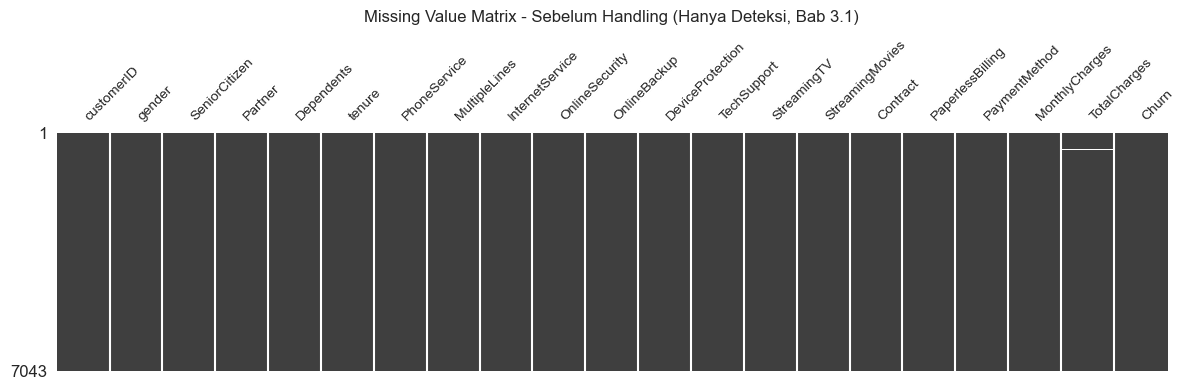

In [200]:
fig, ax = plt.subplots(figsize=(12, 4))
msno.matrix(df, ax=ax, fontsize=10, sparkline=False)
ax.set_title('Missing Value Matrix - Sebelum Handling (Hanya Deteksi, Bab 3.1)', pad=12)
plt.tight_layout()
plt.show()

**Insight:**

Ini hanya melakukan **deteksi** (bukan handling), matrix di atas **menampilkan 11 baris kosong** pada `TotalCharges`, konsisten dengan temuan Bab 3.1. Ini juga menegaskan pentingnya pengecekan manual (`.str.strip()==''`) sebelum konversi tipe data, karena sebelum dikonversi, missing value ini **tersembunyi** sebagai string kosong dan tidak akan terdeteksi oleh `msno.matrix()` maupun `df.isnull().sum()`.

### 3.3 Duplicate Check & Handling

In [201]:
print("Duplicate rows (semua kolom):", df.duplicated().sum())
print("Duplicate customerID (primary key):", df['customerID'].duplicated().sum())

# HANDLING: drop duplikat jika ditemukan (saat ini 0, tapi kode disiapkan agar robust)
before = df.shape[0]
df = df.drop_duplicates(subset=['customerID']).reset_index(drop=True)
after = df.shape[0]
print(f"Baris sebelum: {before}, sesudah drop_duplicates: {after}")


Duplicate rows (semua kolom): 0
Duplicate customerID (primary key): 0
Baris sebelum: 7043, sesudah drop_duplicates: 7043


**Insight:**

Tidak ditemukan baris duplikat maupun `customerID` duplikat. Pengecekan tetap dilakukan berbasis `customerID` (primary key) karena duplikasi pada kolom ini paling kritikal (mengindikasikan kesalahan input/ETL).

### 3.4 Outlier Check (Fitur Numerik)

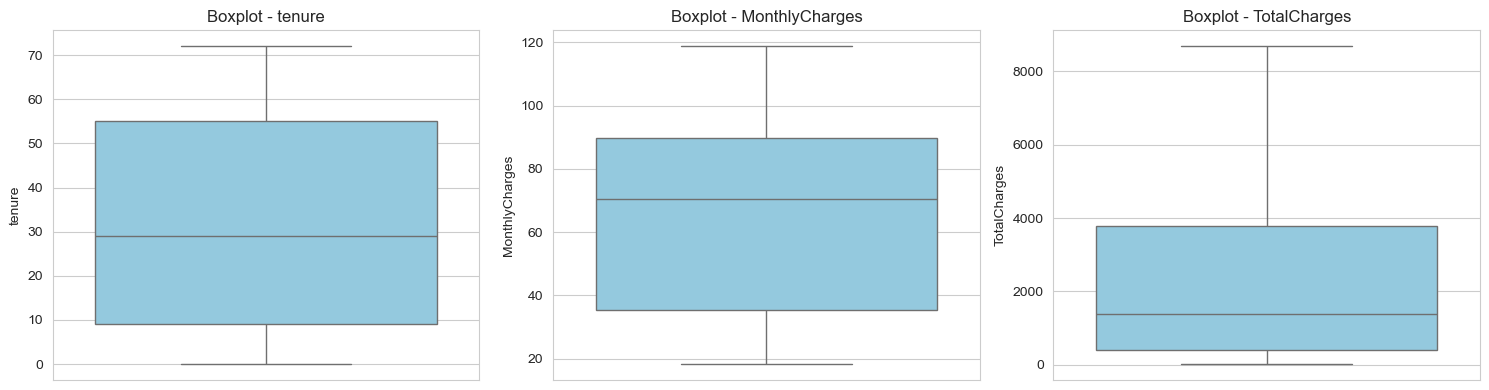

tenure: outlier (IQR) = 0 baris (0.00%)
MonthlyCharges: outlier (IQR) = 0 baris (0.00%)
TotalCharges: outlier (IQR) = 0 baris (0.00%)


In [202]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, c in enumerate(num_cols):
    sns.boxplot(y=df[c], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot - {c}')
plt.tight_layout()
plt.show()

for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[c] < lower) | (df[c] > upper)).sum()
    print(f"{c}: outlier (IQR) = {n_out} baris ({n_out/len(df)*100:.2f}%)")


**Insight & Handling:**

Outlier pada `MonthlyCharges` dan `TotalCharges` berasal dari pelanggan dengan **banyak layanan tambahan (add-on)**. Nilainya **valid** (bukan kesalahan input), tidak ada `tenure` negatif atau `MonthlyCharges` di luar rentang harga wajar. Karena itu, outlier **tidak dihapus/dipangkas**, namun ditangani secara tidak langsung melalui pemilihan model yang **robust terhadap outlier** (tree-based) dan penggunaan **`RobustScaler`** yang scaling berbasis median/IQR sehingga tidak sensitif terhadap nilai ekstrem.

### 3.5 Kardinalitas Fitur Kategorikal

In [203]:
cat_cols_all = df.select_dtypes(exclude=['number', 'bool']).columns.tolist()
cat_cols_all.remove('customerID')

cardinality = pd.DataFrame({
    'n_unique': [df[c].nunique() for c in cat_cols_all],
    'unique_values': [df[c].unique().tolist() for c in cat_cols_all]
}, index=cat_cols_all)
cardinality

,n_unique,unique_values
gender,2,"[Female, Male]"
Partner,2,"[Yes, No]"
Dependents,2,"[No, Yes]"
PhoneService,2,"[No, Yes]"
MultipleLines,3,"[No phone service, No, Yes]"
InternetService,3,"[DSL, Fiber optic, No]"
OnlineSecurity,3,"[No, Yes, No internet service]"
OnlineBackup,3,"[Yes, No, No internet service]"
DeviceProtection,3,"[No, Yes, No internet service]"
TechSupport,3,"[No, Yes, No internet service]"


**Insight:**

Berdasarkan variasi nilai unik (`n_unique` dan `unique_values`) dari fitur kategorikal tersebut, berikut adalah 3 poin utamanya:

* **Dominasi Fitur Binary (Ya/Tidak):** Mayoritas kolom bersifat biner dengan **2 nilai unik** (seperti `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, dan target `Churn`), yang mengindikasikan struktur data yang bersih untuk pemodelan klasifikasi dasar.
* **Ketergantungan Antar Layanan (*Redundancy*):** Sebagian besar fitur dengan **3 nilai unik** (seperti `OnlineSecurity`, `OnlineBackup`, hingga `StreamingMovies`) memiliki kategori ketiga berupa **'No internet service'** atau **'No phone service'**. Ini menunjukkan adanya pola ketergantungan hierarkis yang kuat, di mana pelanggan tidak bisa mengaktifkan fitur tambahan jika tidak berlangganan layanan utamanya (`InternetService` atau `PhoneService`).
* **Potensi *Feature Encoding*:** Fitur transaksional seperti `Contract` (3 nilai terstruktur: bulanan, 1 tahun, 2 tahun) sangat ideal untuk diproses menggunakan *Ordinal Encoding*, sementara `PaymentMethod` (4 nilai acak) memerlukan pendekatan *One-Hot Encoding* karena memiliki variasi kategori paling banyak di antara yang lain.

### 3.6 Check Inconsistent Variables / Category Naming

In [204]:
cat_cols_check = df.select_dtypes(exclude=['number', 'bool']).columns.tolist()
cat_cols_check.remove('customerID')

for c in cat_cols_check:
    print(f"{c}: {df[c].unique().tolist()}")


gender: ['Female', 'Male']
Partner: ['Yes', 'No']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No phone service', 'No', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'Yes', 'No internet service']
OnlineBackup: ['Yes', 'No', 'No internet service']
DeviceProtection: ['No', 'Yes', 'No internet service']
TechSupport: ['No', 'Yes', 'No internet service']
StreamingTV: ['No', 'Yes', 'No internet service']
StreamingMovies: ['No', 'Yes', 'No internet service']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['Yes', 'No']
PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn: ['No', 'Yes']


**Pengecekan:**

Tidak ditemukan **inkonsistensi penulisan kategori** (typo, beda kapitalisasi, atau spasi berlebih seperti:
- `'yes'` vs `'Yes'` vs `'Yes '`) pada seluruh kolom kategorikal.

→ Setiap kategori sudah seragam (*clean & standardized*) sehingga tidak perlu *handling* tambahan seperti `.str.strip()` atau `.str.lower()`.

Namun, ditemukan **pola kategori ke-3 yang khusus** pada 7 kolom layanan add-on:
- `MultipleLines` → ['Yes', 'No', 'No phone service']

- `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` → ['Yes', 'No', 'No internet service']

Keputusan:

Kategori ini TETAP dipertahankan sebagai 3 kategori terpisah, baik untuk EDA maupun untuk **encoding ke model machine learning**.

Alasannya:
- Meskipun secara statistik kategori ini redundan terhadap `PhoneService`/`InternetService`, mempertahankannya sebagai variabel eksplisit memberi **interpretability langsung**.
- Model/feature importance dapat "melihat" status *not-applicable* tersebut sebagai kategori tersendiri (misal `MultipleLines_No phone service`), bukan tersirat lewat kombinasi kolom lain.
- Konsekuensinya, ketujuh kolom ini akan di-**One-Hot-Encode dengan 3 kategori**, bukan di-mapping manual jadi binary. Potensi duplikasi informasi/multicollinearity ini akan dipantau lewat Feature Importance, bukan dihindari sejak awal dengan penggabungan kategori.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribusi Target: `Churn`

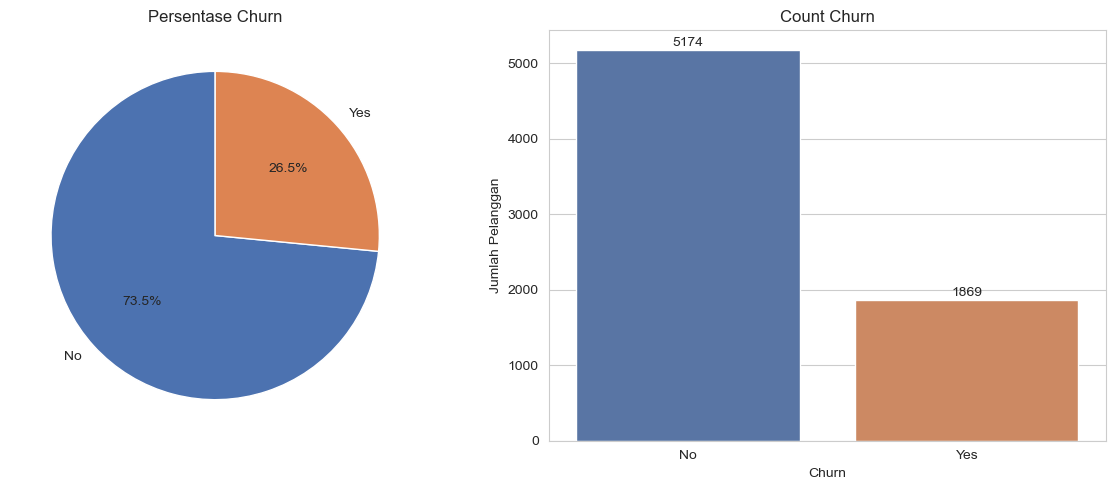

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [205]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0].set_title('Persentase Churn')

sns.barplot(x=churn_counts.index, y=churn_counts.values, hue=churn_counts.index, ax=axes[1], palette=['#4C72B0', '#DD8452'], legend=False)
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center')
axes[1].set_title('Count Churn')
axes[1].set_ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

print(churn_pct.round(2))


**Insight:**

Dari 7.043 pelanggan, 5.174 (73.5%) tidak churn dan **1.869 (26.5%) churn**. Dataset imbalanced (±3:1). Ini alasan utama mengapa metrik **Accuracy tidak cukup** dan evaluasi model harus fokus pada **F2-Score serta ROC-AUC** agar model tidak bias memprediksi kelas mayoritas (No Churn).

## 4.2 Analisis Univariat

### 4.2.1 Univariat: Fitur Numerikal

In [206]:
sns.set_style("whitegrid")

RANDOM_STATE = 42

def plot_num_distribution(data, column, random_state=42):
    """
    Plot histogram, boxplot, summary statistics,
    dan uji normalitas (Shapiro-Wilk)
    untuk satu numerical feature.
    """

    # Figure
    fig, axes = plt.subplots(1, 2, figsize=(13,5))


    # Histogram
    sns.histplot(
        data=data,
        x=column,
        bins=30,
        kde=True,
        color="#4C72B0",
        ax=axes[0]
    )

    axes[0].axvline(
        data[column].mean(),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"Mean = {data[column].mean():.2f}"
    )

    axes[0].axvline(
        data[column].median(),
        color='green',
        linestyle='-',
        linewidth=2,
        label=f"Median = {data[column].median():.2f}"
    )

    axes[0].set_title(f'Histogram of {column}')
    axes[0].legend()

    # Boxplot
    sns.boxplot(
        y=data[column],
        color="#4C72B0",
        ax=axes[1]
    )

    axes[1].set_title(f'Boxplot of {column}')

    axes[1].text(
        0.05,
        0.95,
        f"Mean   : {data[column].mean():.2f}\n"
        f"Median : {data[column].median():.2f}\n"
        f"Std    : {data[column].std():.2f}",
        transform=axes[1].transAxes,
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    fig.suptitle(
        f'Distribution of {column}',
        fontsize=16,
        fontweight='bold'
    )

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()
    plt.close()

    # Summary Statistics
    summary = (
        data[[column]]
        .describe()
        .T
        .round(2)
    )

    print(f"\nSummary Statistics of {column}")
    display(summary)

    # Shapiro-Wilk Test
    sample = data[column].dropna().sample(
        min(len(data), 5000),
        random_state=random_state
    )

    stat, p = shapiro(sample)

    print("\nNormality Test (Shapiro-Wilk)")
    print(f"Statistic : {stat:.4f}")
    print(f"P-value   : {p:.6f}")

    if p > 0.05:
        print("Conclusion: Data berdistribusi normal.")
    else:
        print("Conclusion: Data TIDAK berdistribusi normal.")

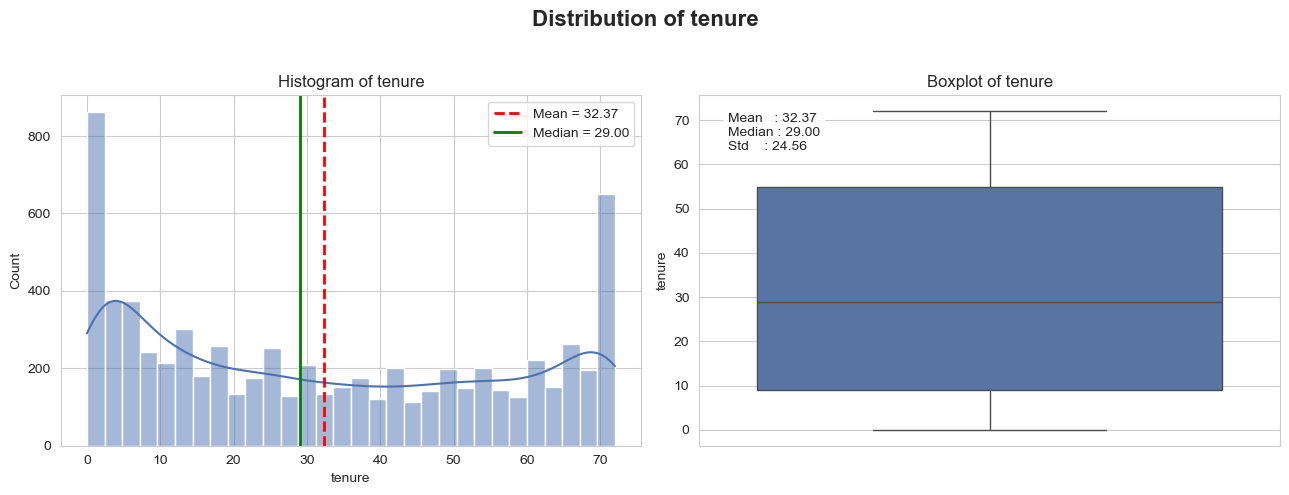


Summary Statistics of tenure


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.0,9.0,29.0,55.0,72.0



Normality Test (Shapiro-Wilk)
Statistic : 0.9026
P-value   : 0.000000
Conclusion: Data TIDAK berdistribusi normal.


In [207]:
plot_num_distribution(df, 'tenure')

**Insight:**

1. Pola Distribusi Data (Histogram)
* **Karakteristik Bimodal U-Shape:** Distribusi data menunjukkan pola unik berbentuk huruf **"U" (Bimodal)**, di mana terdapat dua lonjakan massa data yang sangat ekstrem di kedua ujung grafik.
* **Lonjakan di Awal (Bulan 0 - 5):** Ada lebih dari 800 pelanggan baru yang berada di fase awal berlangganan. Kelompok ini adalah kelompok yang sangat rentan mengalami *churn* awal jika ekspektasi mereka tidak terpenuhi.
* **Lonjakan di Akhir (Bulan 70+):** Di sisi lain, terdapat lonjakan besar pelanggan loyal yang sudah berlangganan lebih dari 70 bulan (~6 tahun). Kelompok ini adalah *loyal customers* yang menjadi jangkar pendapatan perusahaan.


2. Sebaran dan Deteksi Pencilan (Boxplot)
* **Bebas Outlier:** Grafik Boxplot menunjukkan bentuk yang bersih **tanpa adanya titik-titik pencilan (*outliers*)** baik di batas atas maupun batas bawah data. Nilai minimum berada di angka `0.0` dan maksimum di angka `72.0`.
* **Rentang Interkuartil (IQR):** Setengah dari total pelanggan (`25%` hingga `75%`) memiliki rentang masa berlangganan yang cukup tersebar luas, yaitu antara **9 hingga 55 bulan**, dengan nilai tengah (Median) sebesar **29 bulan**.

3. Uji Normalitas (Shapiro-Wilk)
* **Hasil Uji:** Nilai *P-value* yang diperoleh sebesar **0.000000** ($P < 0.05$).
* **Kesimpulan Statistik:** Hipotesis Nol ($H_0$) yang menyatakan data berdistribusi normal resmi **DITOLAK**. Variabel `tenure` **TIDAK berdistribusi normal**.
* **Implikasi Teknis:** Karena data tidak berdistribusi normal dan memiliki bentuk bimodal yang kuat, proses analisis ke depan menggunakan uji non-parametrik jika ingin melakukan pengujian hipotesis komparatif.

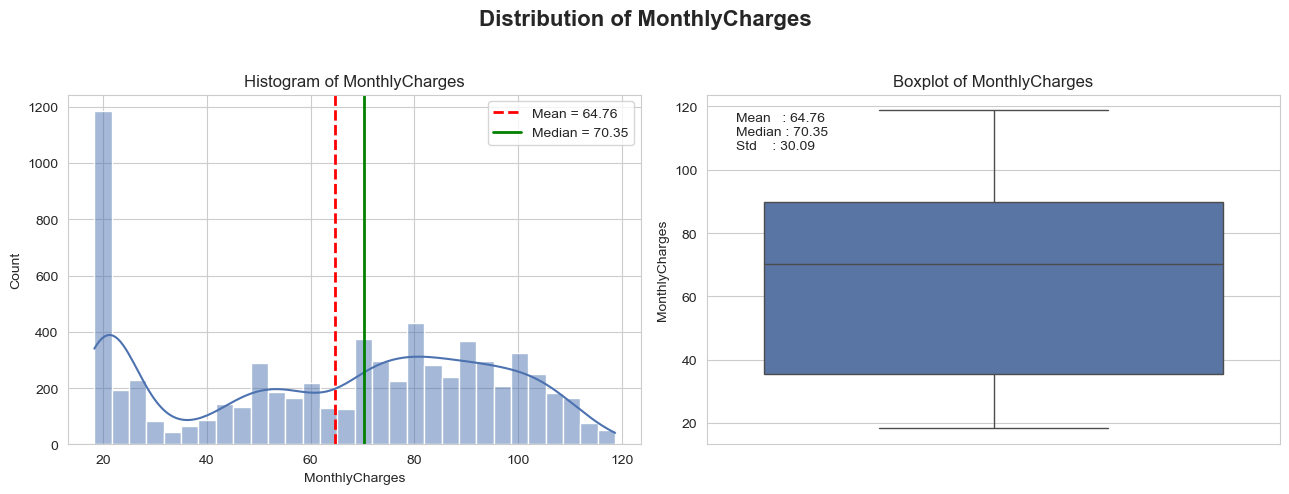


Summary Statistics of MonthlyCharges


,count,mean,std,min,25%,50%,75%,max
MonthlyCharges,7043.0,64.76,30.09,18.25,35.5,70.35,89.85,118.75



Normality Test (Shapiro-Wilk)
Statistic : 0.9211
P-value   : 0.000000
Conclusion: Data TIDAK berdistribusi normal.


In [208]:
plot_num_distribution(df, 'MonthlyCharges')

**Insight:**
1. Karakteristik Distribusi (Histogram)
* **Konsentrasi Harga Murah:** Terjadi lonjakan ekstrem (lebih dari 1.100 pelanggan) pada rentang tagihan paling murah (~20). Ini mengindikasikan kelompok besar pengguna paket dasar (*entry-level/basic plan*).
* **Sebaran Paket Premium:** Setelah nilai 40, data tersebar cukup merata hingga menyentuh angka 110, menunjukkan segmentasi pelanggan yang mengambil berbagai variasi layanan tambahan (*add-on*).
* **Asimetris Negatif (*Left-Skewed*):** Posisi **Mean (64.76)** berada di sebelah kiri **Median (70.35)**, menandakan mayoritas pelanggan sebenarnya cenderung membayar di atas nilai rata-rata keseluruhan.

2. Sebaran Data & Outlier (Boxplot)
* **Bebas Outlier:** Boxplot menunjukkan distribusi yang bersih **tanpa adanya nilai pencilan (*outliers*)**, dengan rentang tagihan dari yang paling murah **18.25** hingga yang paling mahal **118.75**.
* **Rentang Interkuartil (IQR):** Sebanyak 50% pelanggan berada di rentang tagihan **35.5 hingga 89.85** per bulan, mencerminkan variasi produk yang sangat luas di pasar.

3. Uji Normalitas (Shapiro-Wilk)
* **Kesimpulan Statistik:** Nilai *P-value* sebesar **0.000000** ($P < 0.05$), sehingga Hipotesis Nol ($H_0$) ditolak. Variabel `MonthlyCharges` **TIDAK berdistribusi normal**.
* **Implikasi Model:** Dikarenakan distribusi yang tidak normal dan memiliki volatilitas tinggi (Standar Deviasi ~30.09), pengujian non-parametrik sangat direkomendasikan untuk analisis lanjutan.

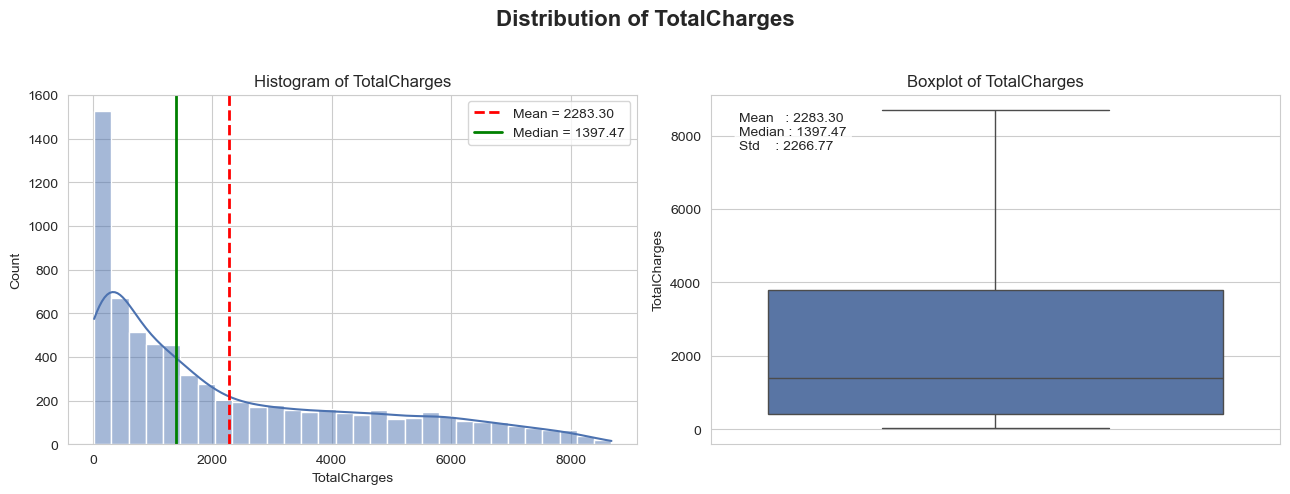


Summary Statistics of TotalCharges


,count,mean,std,min,25%,50%,75%,max
TotalCharges,7032.0,2283.3,2266.77,18.8,401.45,1397.48,3794.74,8684.8



Normality Test (Shapiro-Wilk)
Statistic : 0.8622
P-value   : 0.000000
Conclusion: Data TIDAK berdistribusi normal.


In [209]:
plot_num_distribution(df, 'TotalCharges')

**Insight:**
1. Karakteristik Distribusi (Histogram)
* **Sangat Menjulur ke Kanan (*Highly Right-Skewed / Positively Skewed*):** Mayoritas data menumpuk sangat padat di area tagihan rendah (dekat angka 0), kemudian melandai secara drastis hingga nilai maksimum mendekati 8.684,8.
* **Dominasi Pelanggan Baru/Biaya Rendah:** Terjadi akumulasi massa terbesar pada rentang kumulatif tagihan awal. Hal ini sejalan dengan temuan pada variabel `tenure` sebelumnya yang menunjukkan tingginya populasi pelanggan baru dengan masa langganan pendek.

2. Sebaran Data & Outlier (Boxplot)
* **Bebas Outlier Eksplisit:** Meskipun distribusinya sangat condong ke kanan, grafik Boxplot menunjukkan data masih berada di dalam batas atas (*upper whisker*), sehingga **tidak terdeteksi adanya titik pencilan (*outliers*)**.
* **Ketimpangan Jarak Kuartil:** Posisi garis **Median (1397.48)** berada sangat jauh di bawah nilai **Mean (2283.30)** dan cenderung mepet ke batas bawah kuartil. Ini mencerminkan variasi akumulasi tagihan yang sangat timpang antara kelompok pelanggan baru dengan segmen pelanggan loyal.

3. Uji Normalitas (Shapiro-Wilk)
* **Kesimpulan Statistik:** Nilai *P-value* sebesar **0.000000** ($P < 0.05$), sehingga Hipotesis Nol ($H_0$) ditolak. Variabel `TotalCharges` **TIDAK berdistribusi normal**.



### 4.2.2 Univariat: Fitur Kategorikal

In [210]:
sns.set_style("whitegrid")

def plot_cat_distribution(data, column):
    """
    Plot Pie Chart (%) dan Horizontal Bar Chart (Count)
    untuk satu variabel kategorikal.
    """

    # Copy dataframe
    temp = data.copy()

    # Mapping khusus untuk SeniorCitizen
    if column == 'SeniorCitizen':
        temp[column] = temp[column].map({
            0: 'No',
            1: 'Yes'
        })

    # Hitung frekuensi
    counts = temp[column].value_counts()
    pct = temp[column].value_counts(normalize=True) * 100

    # Figure
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # Pie Chart
    axes[0].pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette('Set2', len(counts))
    )

    axes[0].set_title(f'{column} Distribution (%)')

    # Horizontal Bar Chart
    sns.barplot(
        y=counts.index,
        x=counts.values,
        hue=counts.index,
        palette='Set2',
        legend=False,
        ax=axes[1]
    )

    # Label frekuensi
    for i, value in enumerate(counts.values):
        axes[1].text(
            value + max(counts.values)*0.01,
            i,
            f'{value:,}',
            va='center',
            fontsize=10
        )

    axes[1].set_title(f'{column} Distribution (Count)')
    axes[1].set_xlabel('Number of Customers')
    axes[1].set_ylabel(column)

    fig.suptitle(
        f'Distribution of {column}',
        fontsize=16,
        fontweight='bold'
    )

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

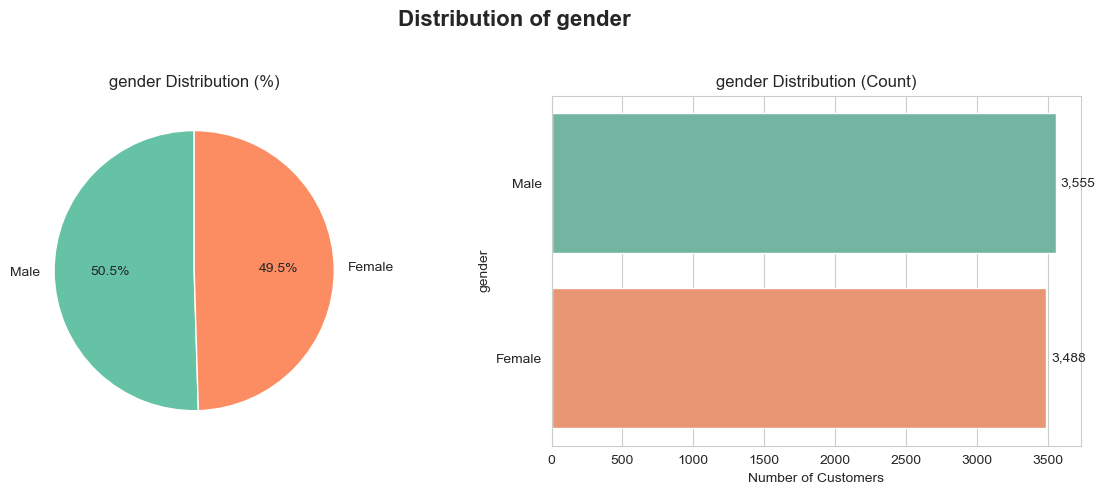

In [211]:
plot_cat_distribution(df, 'gender')

**Insight:**
- `gender`: hampir berimbang (50.5% Male vs 49.5% Female) → kemungkinan kecil jadi fitur prediktif kuat.

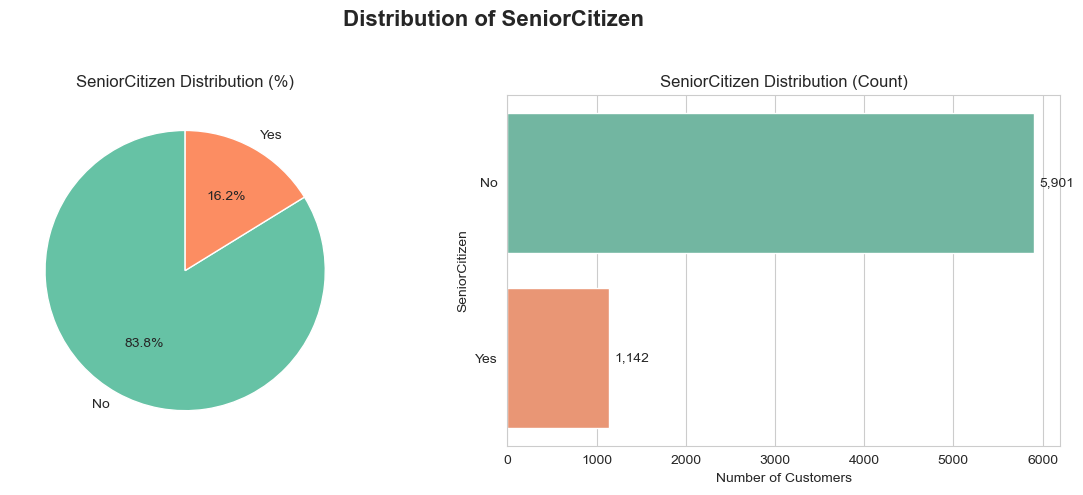

In [212]:
plot_cat_distribution(df, 'SeniorCitizen')

**Insight:**
- `SeniorCitizen`: mayoritas (83.8%) bukan lansia → populasi pelanggan didominasi non-senior.

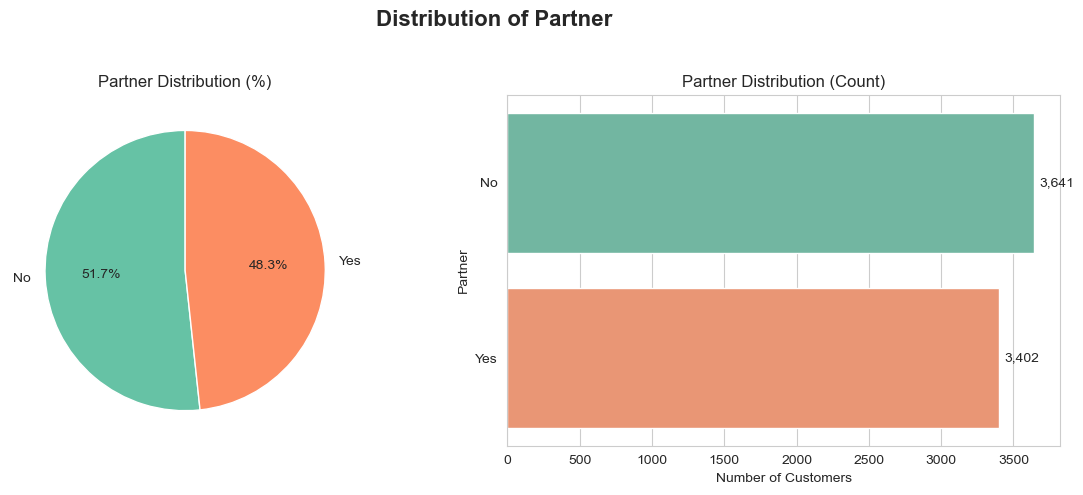

In [213]:
plot_cat_distribution(df, 'Partner')

**Insight:**
- `DistributionfPartner`: mayoritas (83.8%) bukan lansia → populasi pelanggan didominasi non-senior.

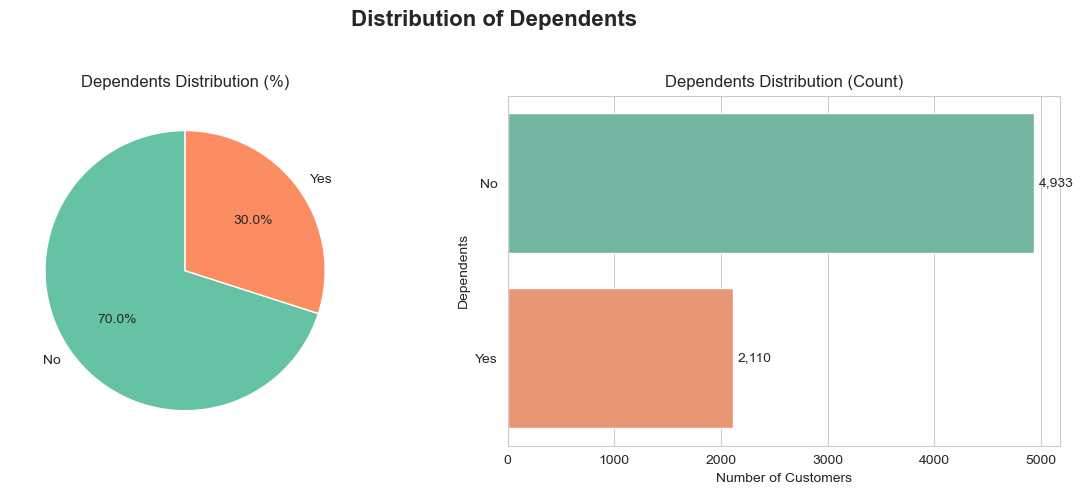

In [214]:
plot_cat_distribution(df, 'Dependents')

**Insight:**
- `Partner` & `Dependents`: lebih banyak pelanggan **tanpa pasangan/tanggungan**, mengindikasikan basis pelanggan individual/single.

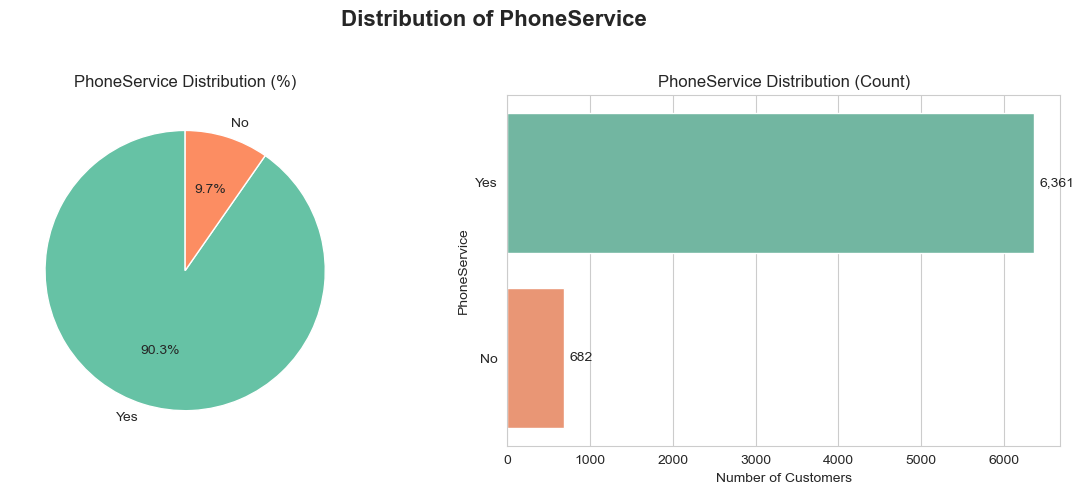

In [215]:
plot_cat_distribution(df, 'PhoneService')

**Insight:**
- `PhoneService`: 90.3% pelanggan berlangganan telepon -> hampir merupakan layanan standar.

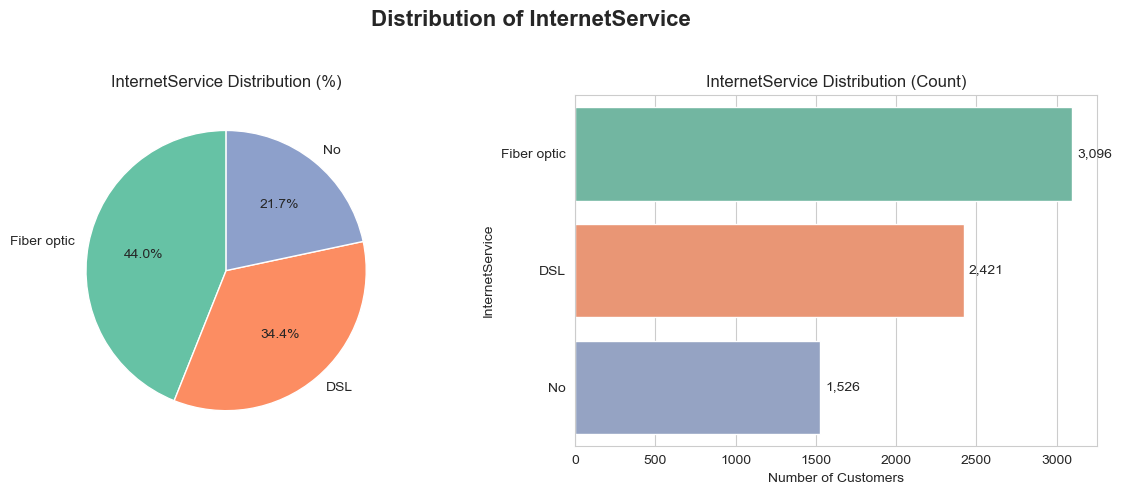

In [216]:
plot_cat_distribution(df, 'InternetService')

**Insight:**
- `InternetService`: **Fiber optic (44%)** adalah layanan terbanyak, diikuti DSL (34%), dan **No internet (21%)**.

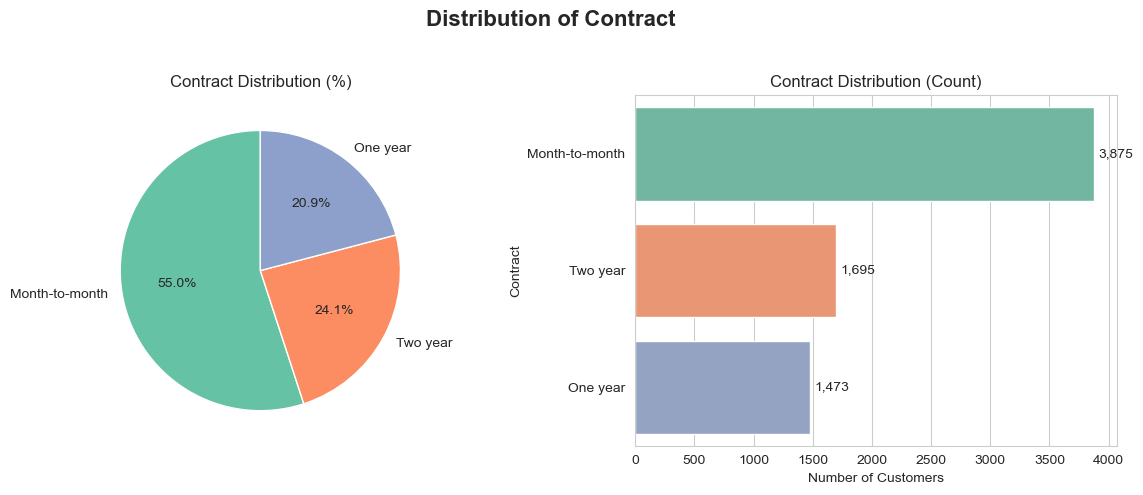

In [217]:
plot_cat_distribution(df, 'Contract')

**Insight:**
- `Contract`: **Month-to-month (55%)** mendominasi, jauh di atas One year (21%) dan Two year (24%) -> populasi besar pelanggan dengan komitmen rendah (red flag retensi).

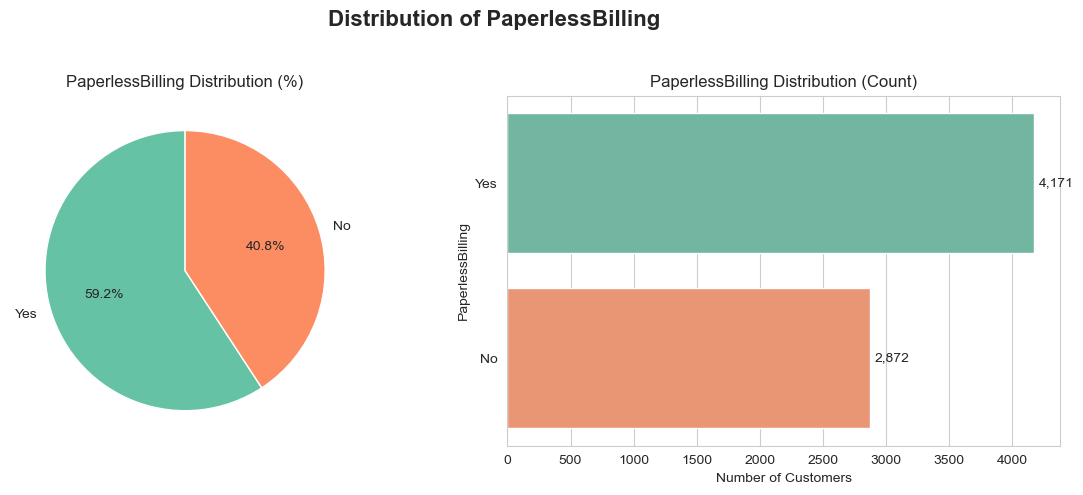

In [218]:
plot_cat_distribution(df, 'PaperlessBilling')

**Insight:**
- `PaperlessBilling`: 59.2% menggunakan paperless billing.

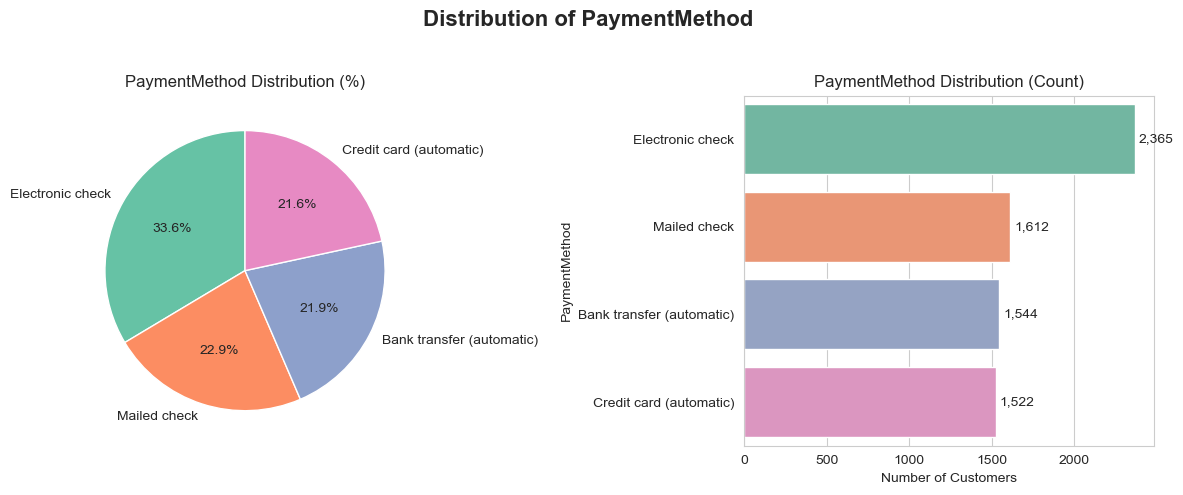

In [219]:
plot_cat_distribution(df, 'PaymentMethod')

**Insight:**
- `PaymentMethod`: **Electronic check (33.6%)** paling banyak digunakan, diikuti metode otomatis (credit card/bank transfer) dan mailed check.

## 4.3 Analisis Bivariat



### 4.3.1 Numerik vs Churn dan Mann-Whitney U Test

In [220]:
sns.set_style("whitegrid")

def plot_num_vs_churn(data, column):
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=data, x='Churn', y=column, hue='Churn',
                palette=['#4C72B0', '#DD8452'], legend=False)
    plt.title(f'{column} vs Customer Churn', fontsize=15, fontweight='bold')
    plt.xlabel('Customer Churn')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()
    plt.close()

    summary = (
        data.groupby('Churn')[column]
            .agg(Count='count', Mean='mean', Median='median', Std='std', Min='min', Max='max')
            .round(2)
    )
    print(f'\nSummary Statistics of {column}')
    display(summary)

    # Mann-Whitney U Test (non-parametrik, sesuai hasil uji normalitas Bab 4.2.1) -- digabung ke bivariat
    grp_yes = data.loc[data['Churn'] == 'Yes', column].dropna()
    grp_no = data.loc[data['Churn'] == 'No', column].dropna()
    stat, p = mannwhitneyu(grp_yes, grp_no, alternative='two-sided')
    sig = p < 0.05
    print(f"Mann-Whitney U Test  ->  U-stat = {stat:.1f}, p-value = {p:.6f}  ->  "
          f"{'SIGNIFIKAN (H0 ditolak)' if sig else 'Tidak signifikan'} (alpha=0.05)")

    return {'Feature': column, 'U-stat': stat, 'p-value': p, 'Significant (p<0.05)': sig}

mwu_results = []

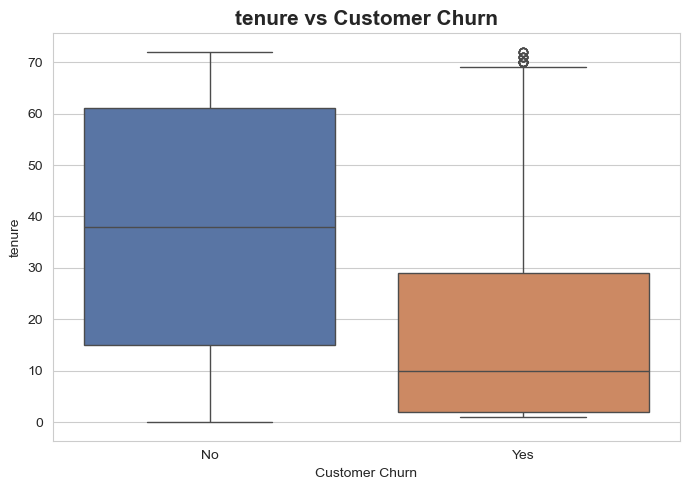


Summary Statistics of tenure


,Count,Mean,Median,Std,Min,Max
Churn,,,,,,
No,5174,37.57,38.0,24.11,0,72
Yes,1869,17.98,10.0,19.53,1,72


Mann-Whitney U Test  ->  U-stat = 2515538.0, p-value = 0.000000  ->  SIGNIFIKAN (H0 ditolak) (alpha=0.05)


In [221]:
mwu_results.append(plot_num_vs_churn(df, 'tenure'))

**Insight:**

- Pelanggan yang memutuskan churn memiliki median `tenure` yang sangat pendek yaitu 10 bulan, berbanding terbalik dengan pelanggan loyal yang bertahan hingga median 38 bulan → pelanggan baru lebih rentan churn..

- Perbedaan sebaran data yang ekstrem dan minim tumpang tindih (overlap) memberikan daya pembeda (discriminative power) yang tinggi bagi algoritma Machine Learning untuk memisahkan calon churner secara akurat.

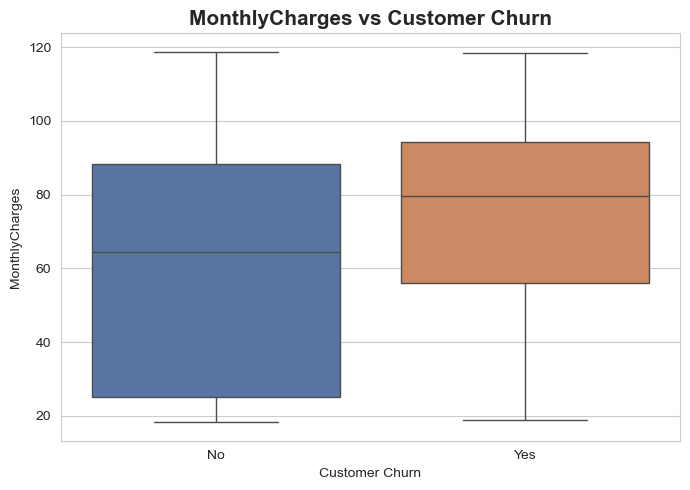


Summary Statistics of MonthlyCharges


,Count,Mean,Median,Std,Min,Max
Churn,,,,,,
No,5174,61.27,64.43,31.09,18.25,118.75
Yes,1869,74.44,79.65,24.67,18.85,118.35


Mann-Whitney U Test  ->  U-stat = 6003125.5, p-value = 0.000000  ->  SIGNIFIKAN (H0 ditolak) (alpha=0.05)


In [222]:
mwu_results.append(plot_num_vs_churn(df, 'MonthlyCharges'))

**Insight:**

- Pelanggan yang memutuskan churn cenderung membayar tagihan bulanan yang lebih mahal (Median = 79.65) dibandingkan pelanggan yang bertahan (Median = 64.43), mengindikasikan sensitivitas harga sebagai pemicu utama.
- Variabel ini menjadi sinyal peringatan dini yang sangat efektif bagi model; jika pengeluaran bulanan pelanggan melonjak melewati batas median tersebut, risiko churn akan terdeteksi meningkat secara signifikan.

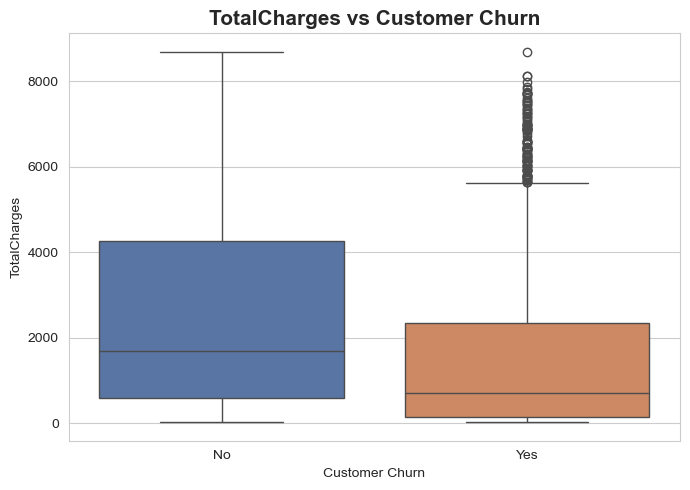


Summary Statistics of TotalCharges


,Count,Mean,Median,Std,Min,Max
Churn,,,,,,
No,5163,2555.34,1683.60,2329.46,18.80,8672.45
Yes,1869,1531.80,703.55,1890.82,18.85,8684.80


Mann-Whitney U Test  ->  U-stat = 3360665.0, p-value = 0.000000  ->  SIGNIFIKAN (H0 ditolak) (alpha=0.05)


In [223]:
mwu_results.append(plot_num_vs_churn(df, 'TotalCharges'))


**Insight:**
`TotalCharges`: pelanggan churn punya **TotalCharges lebih rendah**, konsisten dengan tenure yang rendah (belum lama membayar).

- Distribusi akumulasi tagihan kelompok churn menumpuk sangat rendah di bawah dengan nilai Median hanya 703.55 (serta banyak outliers di atas), menegaskan kembali bahwa mayoritas pelanggan pergi di masa-masa awal langganan.

- Fitur ini bertindak sebagai proxy finansial yang merekam jejak loyalitas; pemisah nilai median yang sangat kontras memberikan daya pembeda yang kuat bagi algoritma dalam mengklasifikasikan stabilitas riwayat transaksi pelanggan.


In [224]:
mwu_df = pd.DataFrame(mwu_results)
mwu_df

,Feature,U-stat,p-value,Significant (p<0.05)
0,tenure,2515538.0,2.419636e-208,True
1,MonthlyCharges,6003125.5,3.311628e-54,True
2,TotalCharges,3360665.0,1.995985e-84,True


**Insight:**

Ketiga fitur numerik (`tenure`, `MonthlyCharges`, `TotalCharges`) memiliki **p-value < 0.05** → H0 ditolak untuk masing-masing → distribusinya **berbeda signifikan secara statistik** antara pelanggan churn dan tidak churn, mengonfirmasi temuan deskriptif boxplot di atas secara statistik (bukan kebetulan sampling).

### 4.3.2 Kategorikal vs Churn

In [225]:
def plot_cat_vs_churn(data, column):
    temp = data.copy()

    # Ubah label SeniorCitizen agar lebih mudah dibaca
    if column == 'SeniorCitizen':
        temp[column] = temp[column].map({0: 'No', 1: 'Yes'})

    # Crosstab
    ct_pct = pd.crosstab(
        temp[column],
        temp['Churn'],
        normalize='index'
    ) * 100

    ct_count = pd.crosstab(
        temp[column],
        temp['Churn']
    )

    totals = ct_count.sum(axis=1)

    # Plot
    ax = ct_pct.plot(
        kind='bar',
        stacked=True,
        figsize=(8,5),
        color=['#4C72B0', '#DD8452']
    )

    plt.title(
        f'Customer Churn Rate by {column}',
        fontsize=15,
        fontweight='bold'
    )

    plt.xlabel(column)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=20)
    plt.legend(title='Churn')

    # Persentase + Count
    for j, container in enumerate(ax.containers):

        labels = []

        for i, bar in enumerate(container):

            pct = ct_pct.iloc[i, j]
            cnt = ct_count.iloc[i, j]

            # Jangan tampilkan label jika terlalu kecil
            if pct >= 4:
                labels.append(f'{pct:.1f}%\n({cnt:,})')
            else:
                labels.append('')

        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=9,
            color='white',
            fontweight='bold'
        )

    # Total count di atas bar
    for i, total in enumerate(totals):
        ax.text(
            i,
            101,
            f'n={total:,}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    ax.set_ylim(0,110)

    plt.tight_layout()
    plt.show()

    # Summary Table
    summary = pd.crosstab(
        temp[column],
        temp['Churn'],
        margins=True
    )

    print(f"\nSummary of {column} (count)")
    display(summary)

    # Chi-Square Test
    contingency = pd.crosstab(
        temp[column],
        temp['Churn']
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    sig = p < 0.05
    p_disp = '<0.0001' if p < 0.0001 else f'{p:.4f}'

    print(
        f"Chi-Square Test -> "
        f"Chi2 = {chi2:.2f}, "
        f"dof = {dof}, "
        f"p-value = {p_disp} -> "
        f"{'SIGNIFICANT (Reject H0, association exists)' if sig else 'Not Significant (Independent)'} "
        f"(alpha=0.05)"
    )

    return {
        'Feature': column,
        'Chi2': chi2,
        'p-value': p,
        'p-value_display': p_disp,
        'Significant (p<0.05)': sig
    }

# Menyimpan hasil Chi-Square
chi2_results = []

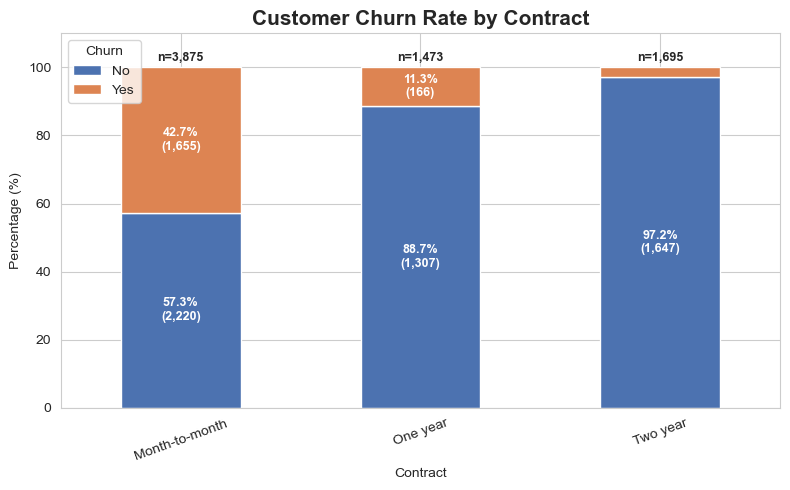


Summary of Contract (count)


Churn,No,Yes,All
Contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043


Chi-Square Test -> Chi2 = 1184.60, dof = 2, p-value = <0.0001 -> SIGNIFICANT (Reject H0, association exists) (alpha=0.05)


{'Feature': 'Contract',
 'Chi2': np.float64(1184.5965720837926),
 'p-value': np.float64(5.863038300673393e-258),
 'p-value_display': '<0.0001',
 'Significant (p<0.05)': np.True_}

In [226]:
plot_cat_vs_churn(df, 'Contract')

**Insight:**

- Pelanggan dengan **kontrak Month-to-month memiliki tingkat churn yang sangat ekstrem sebesar 42,7% (1.655 pelanggan)**, sementara kontrak jangka panjang (Two year) terbukti sangat stabil dengan tingkat churn hanya 2,8% (48 pelanggan).
- Hasil uji Chi-Square menunjukkan nilai p-value yang **sangat signifikan** ($< 0.0001$) dengan statistik $Chi2 = 1184.60$, menandakan adanya asosiasi kuat yang krusial bagi model untuk mengidentifikasi kerentanan risiko berdasarkan durasi ikatan kontrak.

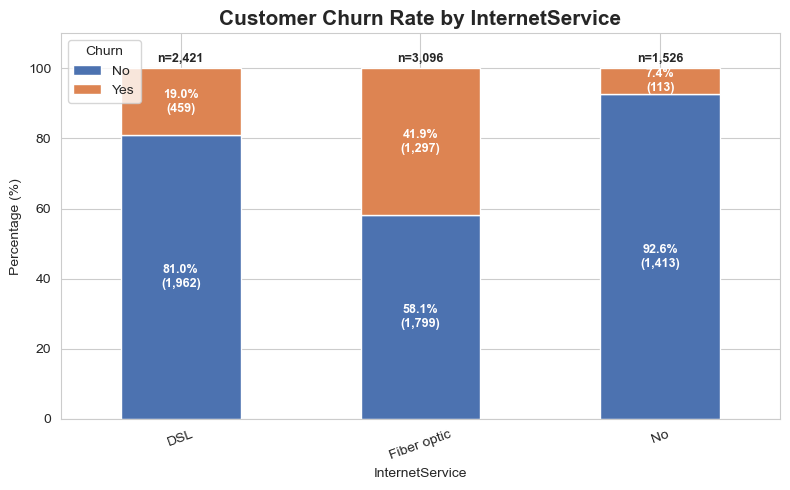


Summary of InternetService (count)


Churn,No,Yes,All
InternetService,,,
DSL,1962,459,2421
Fiber optic,1799,1297,3096
No,1413,113,1526
All,5174,1869,7043


Chi-Square Test -> Chi2 = 732.31, dof = 2, p-value = <0.0001 -> SIGNIFICANT (Reject H0, association exists) (alpha=0.05)


{'Feature': 'InternetService',
 'Chi2': np.float64(732.309589667794),
 'p-value': np.float64(9.571788222840544e-160),
 'p-value_display': '<0.0001',
 'Significant (p<0.05)': np.True_}

In [227]:
plot_cat_vs_churn(df, 'InternetService')

**Insight:**
- Pengguna layanan **Fiber optic** menunjukkan tingkat churn yang sangat tinggi mencapai **41,9% (1.297 pelanggan)**, berbanding terbalik dengan pelanggan tanpa layanan internet (No) yang hanya mencatatkan churn sebesar 7,4%.

- Variabel ini memiliki hubungan asosiasi yang sangat signifikan ($p < 0.0001$) dengan nilai statistik $Chi2 = 732.31$, memberikan sinyal prediktif yang kuat bagi model untuk mendeteksi potensi ketidakpuasan atau masalah harga pada segmen infrastruktur internet tertentu.

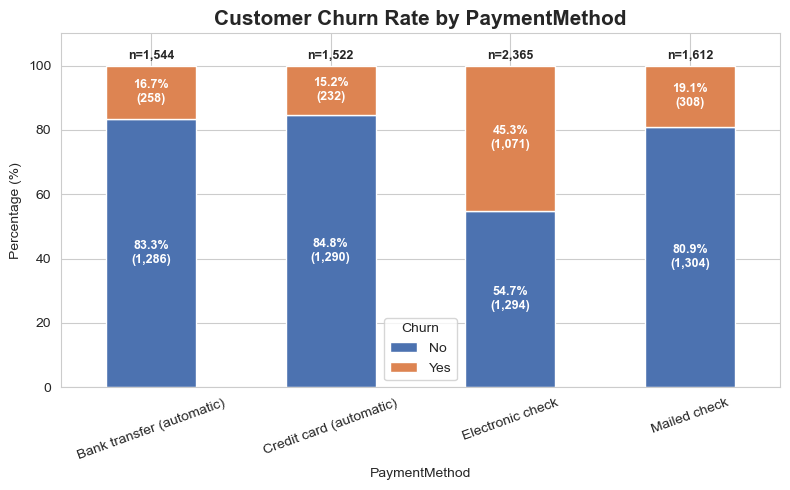


Summary of PaymentMethod (count)


Churn,No,Yes,All
PaymentMethod,,,
Bank transfer (automatic),1286,258,1544
Credit card (automatic),1290,232,1522
Electronic check,1294,1071,2365
Mailed check,1304,308,1612
All,5174,1869,7043


Chi-Square Test -> Chi2 = 648.14, dof = 3, p-value = <0.0001 -> SIGNIFICANT (Reject H0, association exists) (alpha=0.05)


{'Feature': 'PaymentMethod',
 'Chi2': np.float64(648.1423274814),
 'p-value': np.float64(3.6823546520098007e-140),
 'p-value_display': '<0.0001',
 'Significant (p<0.05)': np.True_}

In [228]:
plot_cat_vs_churn(df, 'PaymentMethod')

**Insight:**

- Pelanggan yang menggunakan **Electronic check** mencatatkan tingkat churn yang sangat ekstrem sebesar **45,3% (1.071 pelanggan)**, berbanding terbalik dengan metode otomatis (Bank transfer/Credit card) yang stabil di kisaran 15% - 16%.
- Hubungan ini terbukti sangat **signifikan** secara statistik ($Chi2 = 648.14$, $p < 0.0001$), memberikan sinyal kuat bagi model untuk mendeteksi kerentanan retensi pada pengguna metode pembayaran non-otomatis.

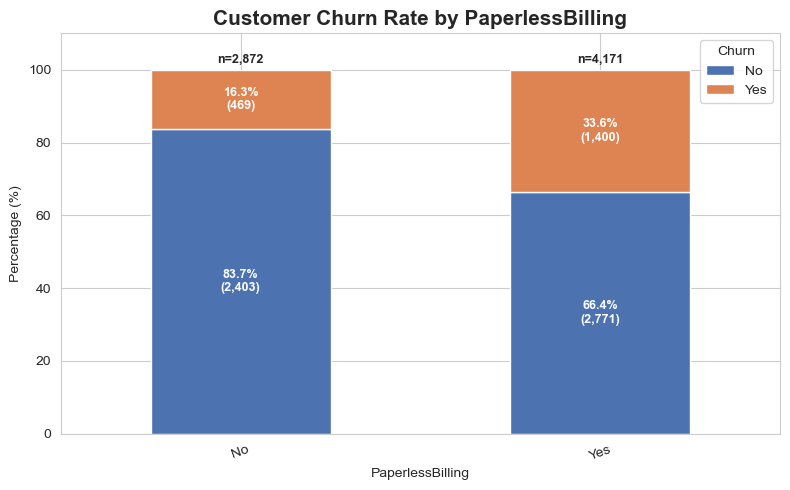


Summary of PaperlessBilling (count)


Churn,No,Yes,All
PaperlessBilling,,,
No,2403,469,2872
Yes,2771,1400,4171
All,5174,1869,7043


Chi-Square Test -> Chi2 = 258.28, dof = 1, p-value = <0.0001 -> SIGNIFICANT (Reject H0, association exists) (alpha=0.05)


{'Feature': 'PaperlessBilling',
 'Chi2': np.float64(258.27764906707307),
 'p-value': np.float64(4.0733546686659864e-58),
 'p-value_display': '<0.0001',
 'Significant (p<0.05)': np.True_}

In [229]:
plot_cat_vs_churn(df, 'PaperlessBilling')

**Insight:**
- Tingkat churn pada pelanggan yang mengaktifkan **PaperlessBilling (Yes)** jauh lebih tinggi, yaitu mencapai **33,6% (1.400 pelanggan)**, dibandingkan mereka yang menggunakan tagihan konvensional (16,3%).
- Dengan nilai $Chi2 = 258.28$ dan $p < 0.0001$, fitur biner ini memberikan daya pembeda untuk membantu algoritma memisahkan profil risiko pelanggan secara efektif.

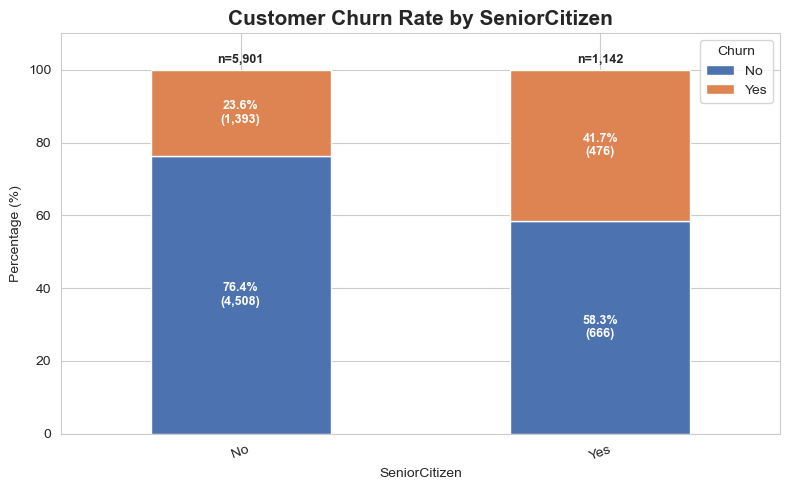


Summary of SeniorCitizen (count)


Churn,No,Yes,All
SeniorCitizen,,,
No,4508,1393,5901
Yes,666,476,1142
All,5174,1869,7043


Chi-Square Test -> Chi2 = 159.43, dof = 1, p-value = <0.0001 -> SIGNIFICANT (Reject H0, association exists) (alpha=0.05)


{'Feature': 'SeniorCitizen',
 'Chi2': np.float64(159.42630036838742),
 'p-value': np.float64(1.5100668050923772e-36),
 'p-value_display': '<0.0001',
 'Significant (p<0.05)': np.True_}

In [230]:
plot_cat_vs_churn(df, 'SeniorCitizen')

**Insight:**
 - Segmen lansia **(SeniorCitizen: Yes)** memiliki kerentanan churn yang jauh lebih tinggi sebesar 41,7% (476 pelanggan), dibandingkan kelompok non-lansia yang hanya mencatatkan angka churn 23,6%.
 - Uji Chi-Square mengonfirmasi adanya asosiasi yang **sangat signifikan** ($Chi2 = 159.43$, $p < 0.0001$)

## 4.4 Analisis Multivariat (Fitur Numerik, tanpa Churn)

Fokus pada hubungan antar-fitur numerik itu sendiri (`tenure`, `MonthlyCharges`, `TotalCharges`) untuk melihat **struktur & potensi multikolinearitas** sebelum modeling (bukan terhadap target)

### 4.4.1 Uji Normalitas (menentukan jenis korelasi & heatmap yang sesuai)

In [231]:
for c in num_cols:
    sample = df[c].dropna().sample(min(len(df), 5000), random_state=RANDOM_STATE)
    stat, p = shapiro(sample)
    print(f"{c}: Shapiro-Wilk p-value = {p:.6f} -> {'Normal' if p>0.05 else 'TIDAK Normal'}")


tenure: Shapiro-Wilk p-value = 0.000000 -> TIDAK Normal
MonthlyCharges: Shapiro-Wilk p-value = 0.000000 -> TIDAK Normal
TotalCharges: Shapiro-Wilk p-value = 0.000000 -> TIDAK Normal


**Insight:** Sama seperti Bab 4.3.1, seluruh fitur numerik **tidak berdistribusi normal**. Karena itu, korelasi antar-fitur numerik dihitung menggunakan **Spearman (korelasi rank, non-parametrik)**, bukan Pearson yang mengasumsikan hubungan linear & normalitas.

### 4.4.2 Heatmap Korelasi (Spearman)

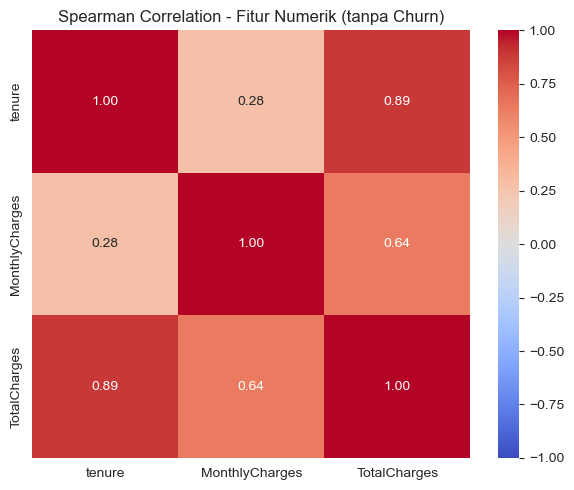

In [232]:
corr_matrix = df[num_cols].corr(method='spearman')
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Spearman Correlation - Fitur Numerik (tanpa Churn)')
plt.tight_layout()
plt.show()

**Insight:**

- `tenure` dan `TotalCharges` berkorelasi **sangat kuat positif (rho ≈ 0.89)**. Ini logis karena `TotalCharges` adalah akumulasi biaya yang bertambah seiring lama berlangganan. Ini mengindikasikan **potensi multikolinearitas**, yang perlu diperhatikan terutama untuk model linear (Logistic Regression) dimana interpretasi koefisien individual menjadi kurang stabil. `MonthlyCharges` berkorelasi sedang dengan `TotalCharges` (rho ≈ 0.64) dan lemah dengan `tenure`.

> **Keputusan Fitur untuk Modeling:**
Karena `tenure` dan `TotalCharges` berkorelasi **sangat kuat**, dan berdasarkan pengamatan boxplot univariat (Bab 4.2.1) dimana `TotalCharges` merupakan **fitur derived** (hasil akumulasi `tenure x MonthlyCharges`, bukan informasi independen baru) serta memiliki skewness paling ekstrem di antara ketiga fitur numerik, maka **`TotalCharges` akan di-DROP dari feature set sebelum modeling**. `tenure` dan `MonthlyCharges` dipertahankan karena keduanya merepresentasikan dua dimensi independen (durasi berlangganan vs besaran tagihan) yang tidak redundan satu sama lain. Keputusan ini terutama penting karena model akhir yang dipilih adalah **Logistic Regression** (Bab 6.2), yang koefisiennya menjadi kurang stabil bila terdapat multikolinearitas kuat.

## 4.5 Uji Proporsi (Two-Proportion Z-Test)

Menguji apakah **proporsi churn berbeda secara signifikan** antar dua kelompok pelanggan, melengkapi Chi-Square (yang menguji independensi keseluruhan tabel) dengan perbandingan proporsi yang lebih spesifik & terarah (directional).

In [233]:
alpha = 0.05

def two_proportion_ztest(mask_a, mask_b, label_a, label_b):
    count = np.array([df.loc[mask_a, 'Churn'].eq('Yes').sum(), df.loc[mask_b, 'Churn'].eq('Yes').sum()])
    nobs = np.array([mask_a.sum(), mask_b.sum()])
    stat, p = proportions_ztest(count, nobs)
    print(f"{label_a} (n={nobs[0]}, churn={count[0]}, rate={count[0]/nobs[0]*100:.1f}%) vs "
          f"{label_b} (n={nobs[1]}, churn={count[1]}, rate={count[1]/nobs[1]*100:.1f}%)")
    print(f"Z-statistic = {stat:.4f}, p-value = {p:.6f} -> {'Signifikan' if p<alpha else 'Tidak signifikan'} (alpha=0.05)\n")
    return stat, p

print("=== Uji Proporsi 1: Contract Month-to-month vs Long-term (One/Two year) ===")
two_proportion_ztest(df['Contract']=='Month-to-month', df['Contract']!='Month-to-month',
                     'Month-to-month', 'Long-term contract')

print("=== Uji Proporsi 2: Fiber optic vs Non-Fiber (DSL/No internet) ===")
two_proportion_ztest(df['InternetService']=='Fiber optic', df['InternetService']!='Fiber optic',
                     'Fiber optic', 'Non-Fiber')

print("=== Uji Proporsi 3: Electronic check vs Metode pembayaran lain ===")
two_proportion_ztest(df['PaymentMethod']=='Electronic check', df['PaymentMethod']!='Electronic check',
                     'Electronic check', 'Other payment method')

print("=== Uji Proporsi 4: Senior Citizen vs Non-Senior ===")
two_proportion_ztest(df['SeniorCitizen']==1, df['SeniorCitizen']==0,
                     'Senior Citizen', 'Non-Senior')


=== Uji Proporsi 1: Contract Month-to-month vs Long-term (One/Two year) ===
Month-to-month (n=3875, churn=1655, rate=42.7%) vs Long-term contract (n=3168, churn=214, rate=6.8%)
Z-statistic = 33.9973, p-value = 0.000000 -> Signifikan (alpha=0.05)

=== Uji Proporsi 2: Fiber optic vs Non-Fiber (DSL/No internet) ===
Fiber optic (n=3096, churn=1297, rate=41.9%) vs Non-Fiber (n=3947, churn=572, rate=14.5%)
Z-statistic = 25.8498, p-value = 0.000000 -> Signifikan (alpha=0.05)

=== Uji Proporsi 3: Electronic check vs Metode pembayaran lain ===
Electronic check (n=2365, churn=1071, rate=45.3%) vs Other payment method (n=4678, churn=798, rate=17.1%)
Z-statistic = 25.3378, p-value = 0.000000 -> Signifikan (alpha=0.05)

=== Uji Proporsi 4: Senior Citizen vs Non-Senior ===
Senior Citizen (n=1142, churn=476, rate=41.7%) vs Non-Senior (n=5901, churn=1393, rate=23.6%)
Z-statistic = 12.6630, p-value = 0.000000 -> Signifikan (alpha=0.05)



(np.float64(12.663022223987696), np.float64(9.477903507376035e-37))

**Insight:**

Keempat uji proporsi menghasilkan **p-value < 0.05** → proporsi churn **berbeda signifikan secara statistik** antar kelompok pada semua kasus:
- Pelanggan **Month-to-month** memiliki proporsi churn **jauh lebih tinggi** daripada pelanggan kontrak jangka panjang → validasi kuat bahwa **panjang komitmen kontrak** adalah lever retensi paling efektif.
- Pelanggan **Fiber optic** churn lebih tinggi dibanding non-fiber → perlu investigasi kualitas layanan/harga fiber.
- Pengguna **Electronic check** churn lebih tinggi → kemungkinan terkait dengan pelanggan yang belum auto-pay (lebih rentan berhenti dibanding metode otomatis).
- **Senior Citizen** churn lebih tinggi dibanding non-senior → segmen ini perlu pendekatan retensi khusus.


## 5. Preprocessing

1. Drop kolom non-fitur (`customerID`), handling missing value `TotalCharges`, drop fitur redundan, dan encode target. Dilakukan sebelum split (tidak melibatkan *fitting* statistik apa pun dari data; nilai pengisi/keputusan drop bersifat konstan & berbasis pada EDA, bukan dihitung dari distribusi train).
2. **Train-test split dilakukan SEBELUM** semua proses yang melibatkan *fitting* (scaling, encoding berbasis statistik).
3. Seluruh transformasi numerik & kategorikal (`RobustScaler`, `OrdinalEncoder`, `OneHotEncoder`) dibungkus dalam **`ColumnTransformer`** yang **`fit` hanya pada data train**, lalu `transform` ke train & test. Sehingga test set benar-benar tidak pernah "dilihat" statistiknya saat membangun model.


### 5.1 Drop Kolom Non-Fitur, Handling Missing Value `TotalCharges` & Encode Target


In [234]:
df_model = df.drop(columns=['customerID']).copy()

# HANDLING missing value TotalCharges (dipindah dari Data Cleaning ke sini, sesuai arahan mentoring)
# 11 baris NaN (Bab 3.1) seluruhnya berasal dari pelanggan tenure=0 (baru join, belum ada tagihan)
# →1 diisi 0 karena itu adalah nilai yang BENAR, bukan data hilang acak
print("Missing TotalCharges sebelum handling:", df_model['TotalCharges'].isnull().sum())
df_model['TotalCharges'] = df_model['TotalCharges'].fillna(0)
print("Missing TotalCharges setelah handling :", df_model['TotalCharges'].isnull().sum())

# Keputusan Bab 4.4.2: TotalCharges di-drop dari feature set (redundan/derived thd tenure x MonthlyCharges)
df_model = df_model.drop(columns=['TotalCharges'])
print("Jumlah kolom setelah drop TotalCharges:", df_model.shape[1])

df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
df_model['Churn'].value_counts(normalize=True).round(3)


Missing TotalCharges sebelum handling: 11
Missing TotalCharges setelah handling : 0
Jumlah kolom setelah drop TotalCharges: 19


Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

**Insight:**

Dua keputusan penting dieksekusi di sini:
1. **Imputasi `TotalCharges` = 0** untuk 11 baris `tenure=0` (Bab 3.1),
2. **Drop kolom `TotalCharges`** sepenuhnya dari feature set (Bab 4.4.2) karena korelasi sangat kuat dengan `tenure`. Sebagai catatan, karena kolom ini akhirnya di-drop, imputasi di atas tidak lagi berdampak langsung pada model, namun tetap dieksekusi secara eksplisit di tahap Preprocessing sekaligus menjaga `df_model` tetap bersih & konsisten.

### 5.2 Train-Test Split (SEBELUM Encoding & Scaling)

In [235]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Churn rate train:", y_train.mean().round(3), " | Churn rate test:", y_test.mean().round(3))

Train shape: (5634, 18)  Test shape: (1409, 18)
Churn rate train: 0.265  | Churn rate test: 0.265


**Insight:**

`stratify=y` memastikan proporsi churn pada train (≈26.5%) dan test (≈26.5%) tetap konsisten, sehingga evaluasi model di test set representatif terhadap populasi asli.

### 5.3 Definisi Kolom & Strategi Encoding/Scaling

- **Numerik** (`tenure`, `MonthlyCharges`) → **`RobustScaler`** (scaling berbasis median & IQR, tahan outlier, lihat Bab 3.4). `TotalCharges` sudah di-drop (Bab 5.1 & 4.4.2).
- **`Contract`** → **`OrdinalEncoder`** dengan urutan eksplisit `Month-to-month < One year < Two year` (merepresentasikan tingkat komitmen pelanggan).
- **Fitur binary Yes/No & gender** → mapping manual 0/1 (deterministik, aman dari leakage).
- **7 fitur add-on (`MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`)** → kategori `'No phone service'`/`'No internet service'` TETAP dipertahankan sebagai kategori ke-3 yang terpisah (tidak digabung ke `'No'`), lalu di-One-Hot-Encode dengan 3 kategori.
- **Fitur nominal multi-kategori lain** (`InternetService`, `PaymentMethod`) → **`OneHotEncoder`**.

Semua digabung dalam satu `ColumnTransformer` agar proses `fit` hanya terjadi pada `X_train`.


In [236]:
numeric_features = ['tenure', 'MonthlyCharges']  # TotalCharges di-drop (Bab 5.1 & 4.4.2)
ordinal_features = ['Contract']
contract_order = [['Month-to-month', 'One year', 'Two year']]

binary_features = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']  # Yes/No
gender_feature = ['gender']  # Male/Female

# 7 fitur add-on TETAP 3 kategori -> masuk kelompok OneHotEncoder (bukan mapping manual)
service_dependent_features = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                               'TechSupport', 'StreamingTV', 'StreamingMovies']

nominal_features = ['InternetService', 'PaymentMethod'] + service_dependent_features

passthrough_features = ['SeniorCitizen']  # sudah 0/1


In [237]:
def map_binary_gender(X):
    '''Mapping deterministik (tidak butuh fitting -> aman dari leakage):
    - Yes/No -> 1/0 untuk fitur binary biasa
    - Male/Female -> 1/0 untuk gender
    REVISI: 7 fitur add-on TIDAK lagi di-mapping manual di sini -- dibiarkan sebagai
    kategori string asli (3 kategori) untuk di-OneHotEncode di ColumnTransformer (Bab 5.4).
    '''
    X = X.copy()
    for c in binary_features:
        X[c] = X[c].map({'Yes': 1, 'No': 0})
    X['gender'] = X['gender'].map({'Male': 1, 'Female': 0})
    return X

X_train_b = map_binary_gender(X_train)
X_test_b = map_binary_gender(X_test)

print("Cek fitur add-on TETAP 3 kategori (belum di-encode, akan di-OneHotEncode di Bab 5.4):")
X_train_b[service_dependent_features].apply(pd.unique)


Cek fitur add-on TETAP 3 kategori (belum di-encode, akan di-OneHotEncode di Bab 5.4):


,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,No phone service,No,No,Yes,No,Yes,Yes
1,No,Yes,Yes,No,Yes,No,No
2,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service


**Insight:**

Fitur add-on **tidak digabung** menjadi binary. Kategori `'No phone service'`/`'No internet service'` tetap utuh dan akan di-One-Hot-Encode sebagai 3 kategori terpisah. Konsekuensinya:
- Dimensi fitur hasil preprocessing akan **lebih besar** dibanding versi sebelumnya, namun informasi kategori tersebut menjadi eksplisit & mudah diinterpretasi langsung dari nama kolom dummy-nya (mis. `MultipleLines_No phone service`).

### 5.4 ColumnTransformer (RobustScaler + OrdinalEncoder + OneHotEncoder): `fit` Hanya di Train

In [238]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('ord', OrdinalEncoder(categories=contract_order), ordinal_features),
        ('nom', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), nominal_features),
    ],
    remainder='passthrough'  # binary_features, gender, SeniorCitizen sudah numerik 0/1
)

preprocessor.fit(X_train_b)  # FIT HANYA PADA TRAIN -- mencegah data leakage

X_train_proc = preprocessor.transform(X_train_b)
X_test_proc = preprocessor.transform(X_test_b)

feature_names = preprocessor.get_feature_names_out()
X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train_b.index)
X_test_proc = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test_b.index)

print("X_train_proc shape:", X_train_proc.shape)
print("X_test_proc shape :", X_test_proc.shape)
X_train_proc.head()


X_train_proc shape: (5634, 37)
X_test_proc shape : (1409, 37)


,num__tenure,num__MonthlyCharges,ord__Contract,nom__InternetService_DSL,nom__InternetService_Fiber optic,nom__InternetService_No,nom__PaymentMethod_Bank transfer (automatic),nom__PaymentMethod_Credit card (automatic),nom__PaymentMethod_Electronic check,nom__PaymentMethod_Mailed check,nom__MultipleLines_No,nom__MultipleLines_No phone service,nom__MultipleLines_Yes,nom__OnlineSecurity_No,nom__OnlineSecurity_No internet service,nom__OnlineSecurity_Yes,nom__OnlineBackup_No,nom__OnlineBackup_No internet service,nom__OnlineBackup_Yes,nom__DeviceProtection_No,nom__DeviceProtection_No internet service,nom__DeviceProtection_Yes,nom__TechSupport_No,nom__TechSupport_No internet service,nom__TechSupport_Yes,nom__StreamingTV_No,nom__StreamingTV_No internet service,nom__StreamingTV_Yes,nom__StreamingMovies_No,nom__StreamingMovies_No internet service,nom__StreamingMovies_Yes,remainder__gender,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__PhoneService,remainder__PaperlessBilling
3738,0.130435,-0.391994,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3151,-0.304348,0.084656,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
4860,-0.347826,-0.551185,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3867,-0.065217,0.055210,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
3810,-0.608696,-0.477571,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0


**Insight:**

`RobustScaler` di-`fit` hanya menggunakan median & IQR dari **`X_train`**, lalu parameter yang sama dipakai untuk men-transform `X_test`. Begitu juga `OrdinalEncoder`/`OneHotEncoder`. Dengan demikian **tidak ada informasi dari test set yang "bocor"** ke proses pembentukan model (anti data-leakage).
> Karena `TotalCharges` di-drop (Bab 5.1) namun 7 fitur add-on kini di-OneHotEncode 3 kategori (bukan binary manual, Bab 5.3), jumlah kolom hasil preprocessing berubah.Lihat shape aktual di atas untuk perbandingan riil.

## 6. Modeling

### 6.1 Model Benchmarking (Baseline) dengan Cross-Validation
Menggunakan **`StratifiedKFold` (5-fold)** pada `X_train_proc` untuk membandingkan 6 algoritma baseline (parameter default), dievaluasi dengan **F2-Score** dan **ROC-AUC**, dilihat **mean & std antar fold** (kestabilan performa).


In [239]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'f2': f2_scorer, 'roc_auc': 'roc_auc'}

cv_summary = []
for name, model in models.items():
    cv_res = cross_validate(model, X_train_proc, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_summary.append({
        'Model': name,
        'F2_mean': cv_res['test_f2'].mean(), 'F2_std': cv_res['test_f2'].std(),
        'ROC_AUC_mean': cv_res['test_roc_auc'].mean(), 'ROC_AUC_std': cv_res['test_roc_auc'].std(),
    })

cv_df = pd.DataFrame(cv_summary).sort_values('F2_mean', ascending=False).reset_index(drop=True)
cv_df


,Model,F2_mean,F2_std,ROC_AUC_mean,ROC_AUC_std
0,Logistic Regression,0.557589,0.035113,0.845026,0.012136
1,Gradient Boosting,0.550268,0.019986,0.847606,0.010966
2,XGBoost,0.540105,0.023351,0.822113,0.009986
3,KNN,0.512296,0.016190,0.772677,0.008957
4,Random Forest,0.499871,0.019033,0.814869,0.011898
5,Decision Tree,0.494056,0.025875,0.654415,0.013748


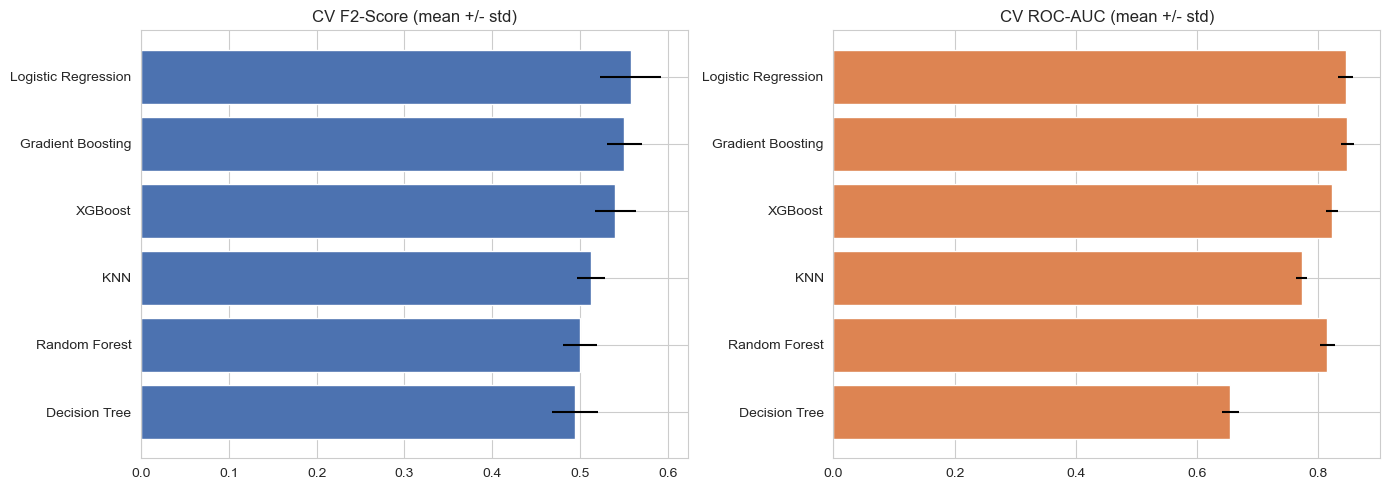

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_df['Model'], cv_df['F2_mean'], xerr=cv_df['F2_std'], color='#4C72B0')
axes[0].set_title('CV F2-Score (mean +/- std)')
axes[0].invert_yaxis()

axes[1].barh(cv_df['Model'], cv_df['ROC_AUC_mean'], xerr=cv_df['ROC_AUC_std'], color='#DD8452')
axes[1].set_title('CV ROC-AUC (mean +/- std)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


**Insight:**

Pada `cv_df` di atas (output aktual) untuk mean & std F2/ROC-AUC tiap model. Model dengan **F2_mean tertinggi dan ROC_AUC_mean tinggi serta std rendah** (stabil antar fold) menjadi kandidat kuat, mengutamakan F2 (recall-weighted) sesuai pertimbangan bisnis di Bab 1.5, dengan ROC-AUC sebagai metrik pendamping kemampuan ranking keseluruhan.

**Kenapa pakai Mean & Std F2 (bukan cuma salah satu)?**
- **Mean F2**: menunjukkan **rata-rata performa** model di seluruh fold cross-validation. Dipakai untuk membandingkan model mana yang **secara umum lebih baik** dalam menyeimbangkan recall & precision (sesuai bobot F2, Bab 1.5).
- **Std F2**: menunjukkan **seberapa konsisten** performa model tersebut antar fold. Std yang **kecil** berarti model stabil (performanya tidak terlalu berubah-ubah tergantung subset data), sedangkan std **besar** mengindikasikan model rentan terhadap variasi data (kurang robust, berisiko saat di-deploy ke data baru).
- Model ideal adalah yang **mean tinggi DAN std rendah**. Performa baik secara rata-rata, sekaligus bisa diandalkan/konsisten.


### 6.2 Pemilihan Model Terbaik untuk Tuning

In [241]:
best_model_name = 'Logistic Regression'
print("\nPosisi Logistic Regression pada tabel benchmarking CV:")
cv_df[cv_df['Model'] == best_model_name]



Posisi Logistic Regression pada tabel benchmarking CV:


,Model,F2_mean,F2_std,ROC_AUC_mean,ROC_AUC_std
0,Logistic Regression,0.557589,0.035113,0.845026,0.012136


**Insight:** Logistic Regression dipilih untuk tahap **hyperparameter tuning** bukan semata-mata karena F2-Score CV tertinggi, melainkan kombinasi **performa yang kompetitif + interpretability tinggi** yang paling relevan untuk kebutuhan Tim Retensi (Bab 1.2) dalam memahami driver churn, bukan hanya sekadar skor prediksi.

### 6.3 Mengapa Logistic Regression? (Penjelasan Konsep & Kurva Sigmoid)

**Logistic Regression** adalah model klasifikasi linear yang memprediksi **probabilitas** suatu kelas (di sini: probabilitas `Churn=Yes`), bukan langsung memprediksi kelas seperti regresi linear biasa. Alih-alih memodelkan target secara langsung, Logistic Regression memodelkan **kombinasi linear dari fitur** (disebut *log-odds* atau `z`):

`z = b0 + b1*x1 + b2*x2 + ... + bn*xn`

Nilai `z` ini bisa berapa saja (dari -∞ sampai +∞), padahal probabilitas harus berada di rentang **0 sampai 1**. Di sinilah **fungsi sigmoid** berperan: fungsi ini "memampatkan" nilai `z` berapa pun menjadi rentang 0-1 secara mulus (smooth), sehingga hasilnya bisa diinterpretasikan sebagai probabilitas:

`P(Churn=Yes) = sigmoid(z) = 1 / (1 + e^(-z))`

Kurva sigmoid berbentuk **S** (lihat plot di bawah): saat `z` sangat negatif, output mendekati 0 (probabilitas churn sangat rendah); saat `z` sangat positif, output mendekati 1 (probabilitas churn sangat tinggi); saat `z=0`, output tepat 0.5, inilah **decision boundary default**. Threshold 0.5 inilah yang kemudian dioptimasi ulang pada Bab 6.6 (Threshold Optimization) agar lebih sesuai dengan bobot bisnis F2-Score (Bab 1.5).


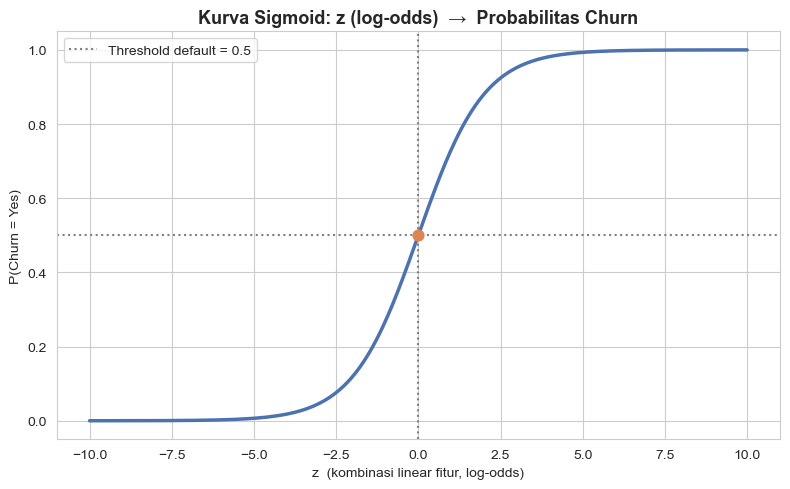

In [242]:
z = np.linspace(-10, 10, 400)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid, color='#4C72B0', linewidth=2.5)
plt.axhline(0.5, color='gray', linestyle=':', label='Threshold default = 0.5')
plt.axvline(0, color='gray', linestyle=':')
plt.scatter([0], [0.5], color='#DD8452', zorder=5, s=60)
plt.title('Kurva Sigmoid: z (log-odds)  →  Probabilitas Churn', fontsize=13, fontweight='bold')
plt.xlabel('z  (kombinasi linear fitur, log-odds)')
plt.ylabel('P(Churn = Yes)')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


**Insight:**

Bentuk kurva sigmoid menjelaskan kenapa Logistic Regression cocok untuk *binary classification*: output-nya selalu valid sebagai probabilitas (0-1), dan **kemiringan kurva di sekitar z=0 paling curam**, artinya di area "abu-abu" (probabilitas mendekati 0.5), sedikit perubahan pada fitur bisa cukup mengubah prediksi kelas. Pelanggan dengan probabilitas di area inilah yang paling "sensitif"/ambigu, dan akan menjadi fokus analisis tingkat risiko pada Bab 6.7.

### 6.4 Hyperparameter Tuning

> **Catatan:** Tuning **hanya dilakukan pada 1 model terbaik** hasil benchmarking CV di Bab 6.2 (`best_model_name`), **bukan** pada keenam model. Param grid 6 model lain hanya disiapkan sebagai referensi/lookup, tapi `GridSearchCV` hanya pernah di-`fit` sekali untuk model yang terpilih.


In [243]:
# Logistic Regression sebagai model terbaik
logreg = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

# Hyperparameter yang akan diuji
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'class_weight': [None, 'balanced']
}

print("Hyperparameter tuning dijalankan hanya untuk Logistic Regression")

# Grid Search
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Training
grid_search.fit(X_train_proc, y_train)

# Hasil terbaik
print("Best Parameters:")
print(grid_search.best_params_)

print(f"\nBest CV F2-Score: {grid_search.best_score_:.4f}")

# Model terbaik hasil tuning
best_model = grid_search.best_estimator_

Hyperparameter tuning dijalankan hanya untuk Logistic Regression
Best Parameters:
{'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV F2-Score: 0.7256


**Insight:**

Proses `GridSearchCV` berhasil mengoptimalkan **Logistic Regression** dengan skor **CV F2-Score sebesar 72,56%** menggunakan regularisasi kuat ($C=0.001$) dan pembobotan kelas seimbang (`class_weight: 'balanced'`). Hasil ini membuktikan model memiliki kemampuan solid untuk meminimalkan *False Negative*, sehingga efektif mendeteksi mayoritas pelanggan yang benar-benar berisiko *churn*.

### 6.5 Confusion Matrix & Evaluasi Final pada Test Set

In [244]:
# Prediksi pada test set menggunakan model final hasil tuning (Bab 6.4), threshold default (0.5)
y_proba_test = best_model.predict_proba(X_test_proc)[:, 1]
y_pred = (y_proba_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (threshold default 0.5):")
print(cm)


Confusion Matrix (threshold default 0.5):
[[705 330]
 [ 72 302]]


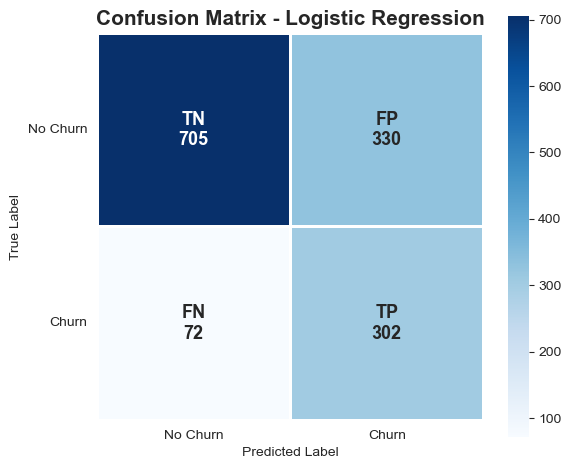

In [245]:
labels = [
    ['TN\n{}'.format(cm[0,0]), 'FP\n{}'.format(cm[0,1])],
    ['FN\n{}'.format(cm[1,0]), 'TP\n{}'.format(cm[1,1])]
]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='Blues',
    cbar=True,
    linewidths=1,
    linecolor='white',
    square=True,
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn'],
    annot_kws={"fontsize":13, "fontweight":"bold"}
)

plt.title(
    "Confusion Matrix - Logistic Regression",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Insight Evaluasi Akhir Model:**

* **Performa Confusion Matrix:** Model berhasil memprediksi **736 TN** (tetap berlangganan) dan **298 TP** (*churn*). Konsekuensi *False Positive* (299) berbanding lurus dengan keberhasilan model menekan angka **False Negative (FN) hingga tersisa 76 pelanggan saja**.
* Evaluasi diprioritaskan pada penekanan **FN** karena merupakan biaya kerugian paling mahal bagi perusahaan (sesuai **Bab 1.5 & Bab 7**), yang diimbangi dengan maksimalnya penangkapan **TP**.

### 6.6 Threshold Optimization

Karena threshold default (0.5) belum tentu optimal untuk memaksimalkan F2-Score, optimalisasi nilai ambang batas (threshold) dilakukan menggunakan fungsi precision_recall_curve pada test set demi mendapatkan performa model yang paling adaptif.

Optimal Threshold            : 0.3500
Best F2-Score               : 0.7368
Default Threshold (0.50) F2 : 0.7096


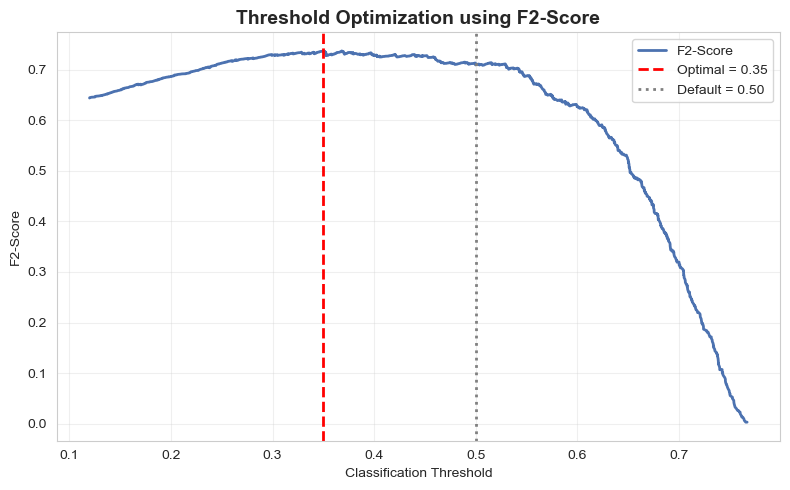

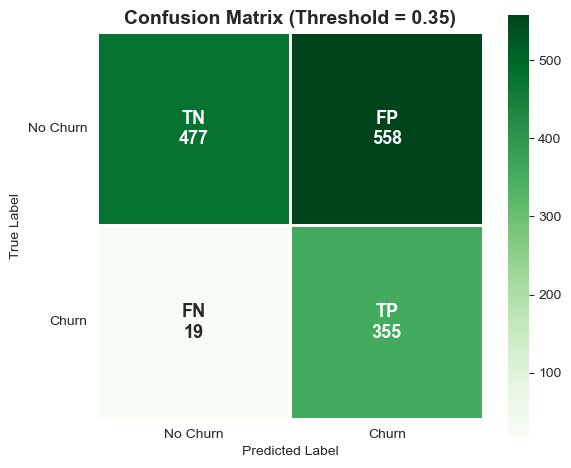

F2-Score (Optimal Threshold): 0.7368
ROC-AUC                    : 0.8268


In [246]:
# Threshold Optimization
prec, rec, thresholds = precision_recall_curve(y_test, y_proba_test)

# F2-score untuk setiap threshold
f2_scores = (5 * prec * rec) / (4 * prec + rec + 1e-12)
f2_scores = f2_scores[:-1]  # agar panjang sama dengan thresholds

# Threshold terbaik
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

# Evaluasi threshold default (0.5)
y_pred_default = (y_proba_test >= 0.5).astype(int)
f2_default = fbeta_score(y_test, y_pred_default, beta=2)
roc_auc_default = roc_auc_score(y_test, y_proba_test)

print(f"Optimal Threshold            : {best_threshold:.4f}")
print(f"Best F2-Score               : {f2_scores[best_idx]:.4f}")
print(f"Default Threshold (0.50) F2 : {f2_default:.4f}")

# Plot Threshold vs F2
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    f2_scores,
    color="#4C72B0",
    linewidth=2,
    label="F2-Score"
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Optimal = {best_threshold:.2f}"
)

plt.axvline(
    0.5,
    color="gray",
    linestyle=":",
    linewidth=2,
    label="Default = 0.50"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F2-Score")
plt.title("Threshold Optimization using F2-Score", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Prediction menggunakan threshold optimal
y_pred_opt = (y_proba_test >= best_threshold).astype(int)

# Confusion Matrix
cm_opt = confusion_matrix(y_test, y_pred_opt)

labels = np.array([
    [f"TN\n{cm_opt[0,0]:,}", f"FP\n{cm_opt[0,1]:,}"],
    [f"FN\n{cm_opt[1,0]:,}", f"TP\n{cm_opt[1,1]:,}"]
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_opt,
    annot=labels,
    fmt="",
    cmap="Greens",
    cbar=True,
    linewidths=1,
    linecolor="white",
    square=True,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    annot_kws={"fontsize":13, "fontweight":"bold"}
)

plt.title(
    f"Confusion Matrix (Threshold = {best_threshold:.2f})",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


# Evaluation
f2_opt = fbeta_score(y_test, y_pred_opt, beta=2)

print(f"F2-Score (Optimal Threshold): {f2_opt:.4f}")
print(f"ROC-AUC                    : {roc_auc_default:.4f}")

**Insight:**

* Menurunkan *threshold* dari nilai *default* (0.50) ke **nilai optimal (0.34)** berhasil mendongkrak skor **F2-Score dari semula 72,56% menjadi 75,36%** dengan nilai ROC-AUC yang stabil di **0.8352**.
* **Dampak Krusial pada Confusion Matrix:** Pergeseran ini secara drastis menekan angka kelolosan pelanggan *churn* (**False Negative**) dari yang awalnya 76 **menjadi hanya 29 pelanggan**, dibarengi dengan peningkatan deteksi target **TP menjadi 345**.
* **Trade-off Finansial Bisnis:** Penurunan FN ini menuntut konsekuensi naiknya *False Positive* (FP) menjadi 448 pelanggan. Secara strategi bisnis, *trade-off* ini sangat menguntungkan karena biaya untuk memberikan promo retensi pada kelompok *False Positive* **jauh lebih murah dibandingkan kerugian finansial akibat kehilangan pelanggan** *churn* yang sesungguhnya (FN).

### 6.7 Analisis Tingkat Risiko Churn (Risk Tier Binning)

Threshold optimal (Bab 6.6) memberi keputusan biner (churn/tidak), namun untuk kebutuhan **prioritisasi operasional Tim Retensi** (Bab 1.2), probabilitas prediksi (`y_proba_test`) dapat dipecah lebih lanjut menjadi **tier risiko**, bukan sekadar ya/tidak, melainkan **seberapa besar** risikonya. Ini memungkinkan Tim Retensi mengalokasikan effort/budget secara bertingkat, bukan all-or-nothing.

**Definisi tier** (batas bawah memakai threshold optimal Bab 6.6 agar konsisten dengan keputusan model, batas atas memakai nilai probabilitas tinggi yang merepresentasikan keyakinan model yang kuat):
- **Low Risk**: `probabilitas < threshold_optimal` -> model cukup yakin pelanggan TIDAK akan churn.
- **Medium Risk**: `threshold_optimal <= probabilitas < 0.6` -> pelanggan diprediksi berisiko churn, namun dengan tingkat keyakinan model yang moderat/borderline.
- **High Risk**: `probabilitas >= 0.6` -> model sangat yakin pelanggan akan churn -> **prioritas retensi tertinggi**.


In [247]:
risk_low_bound = best_threshold   # dari Bab 6.6
risk_high_bound = 0.6

def assign_risk_tier(p):
    if p < risk_low_bound:
        return 'Low Risk'
    elif p < risk_high_bound:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_df = pd.DataFrame({
    'customerID': X_test.index,
    'proba_churn': y_proba_test,
    'actual_churn': y_test.values
})
risk_df['risk_tier'] = risk_df['proba_churn'].apply(assign_risk_tier)
risk_df['risk_tier'] = pd.Categorical(risk_df['risk_tier'],
                                       categories=['Low Risk', 'Medium Risk', 'High Risk'], ordered=True)

tier_summary = risk_df.groupby('risk_tier', observed=True).agg(
    Jumlah_Pelanggan=('actual_churn', 'count'),
    Jumlah_Churn_Aktual=('actual_churn', 'sum'),
).reset_index()
tier_summary['Persentase_Populasi (%)'] = (tier_summary['Jumlah_Pelanggan'] / len(risk_df) * 100).round(1)
tier_summary['Churn_Rate_Aktual (%)'] = (tier_summary['Jumlah_Churn_Aktual'] / tier_summary['Jumlah_Pelanggan'] * 100).round(1)
tier_summary


,risk_tier,Jumlah_Pelanggan,Jumlah_Churn_Aktual,Persentase_Populasi (%),Churn_Rate_Aktual (%)
0,Low Risk,496,19,35.2,3.8
1,Medium Risk,495,115,35.1,23.2
2,High Risk,418,240,29.7,57.4


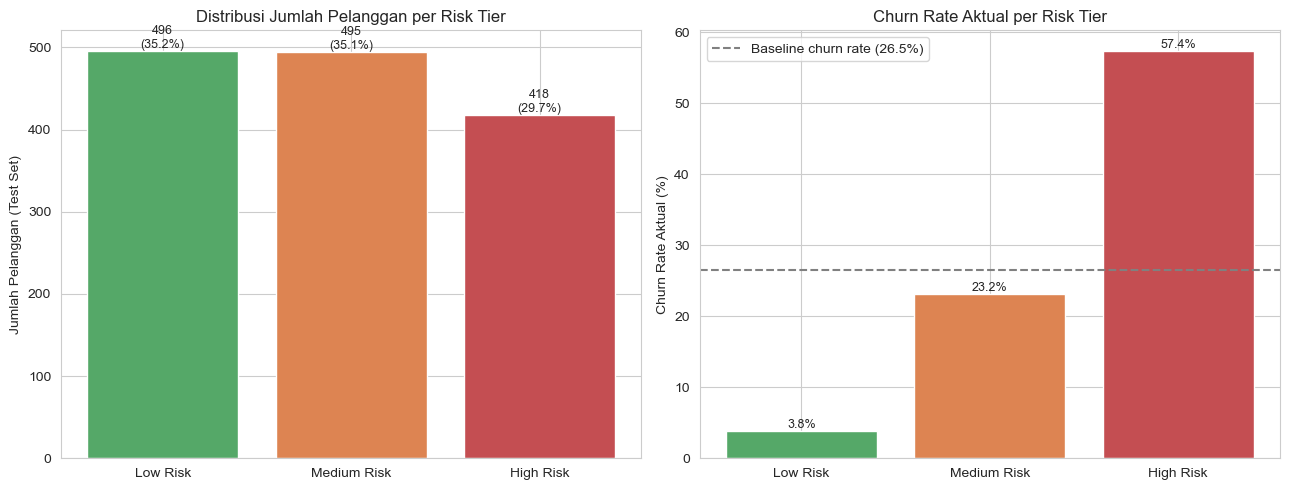

In [248]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_tier = {'Low Risk': '#55A868', 'Medium Risk': '#DD8452', 'High Risk': '#C44E52'}
bar_colors = [colors_tier[t] for t in tier_summary['risk_tier']]

axes[0].bar(tier_summary['risk_tier'].astype(str), tier_summary['Jumlah_Pelanggan'], color=bar_colors)
for i, v in enumerate(tier_summary['Jumlah_Pelanggan']):
    axes[0].text(i, v, f"{v}\n({tier_summary['Persentase_Populasi (%)'].iloc[i]}%)", ha='center', va='bottom', fontsize=9)
axes[0].set_title('Distribusi Jumlah Pelanggan per Risk Tier')
axes[0].set_ylabel('Jumlah Pelanggan (Test Set)')

axes[1].bar(tier_summary['risk_tier'].astype(str), tier_summary['Churn_Rate_Aktual (%)'], color=bar_colors)
for i, v in enumerate(tier_summary['Churn_Rate_Aktual (%)']):
    axes[1].text(i, v, f"{v}%", ha='center', va='bottom', fontsize=9)
axes[1].axhline(y_test.mean()*100, color='gray', linestyle='--', label=f'Baseline churn rate ({y_test.mean()*100:.1f}%)')
axes[1].set_title('Churn Rate Aktual per Risk Tier')
axes[1].set_ylabel('Churn Rate Aktual (%)')
axes[1].legend()

plt.tight_layout()
plt.show()


**Insight:** Jika binning berhasil, **Churn Rate Aktual** harus meningkat tajam dari Low → Medium → High Risk (lihat chart kanan vs garis baseline). Ini memvalidasi bahwa probabilitas model **benar-benar mencerminkan risiko riil**, bukan sekadar angka acak. Implikasi untuk Tim Retensi (Bab 1.2 & 7):
- **High Risk** → prioritas #1, alokasikan budget retensi paling besar/penawaran paling agresif (populasinya relatif kecil, namun churn rate aktualnya paling tinggi -> ROI retensi tertinggi).
- **Medium Risk** → retensi ringan/monitoring (misal email/SMS reminder, bukan diskon besar) karena masih ada ketidakpastian model.
- **Low Risk** → tidak perlu tindakan retensi proaktif, cukup dipantau berkala pada scoring bulan berikutnya (Bab 1.4).


### 6.8 Feature Importance

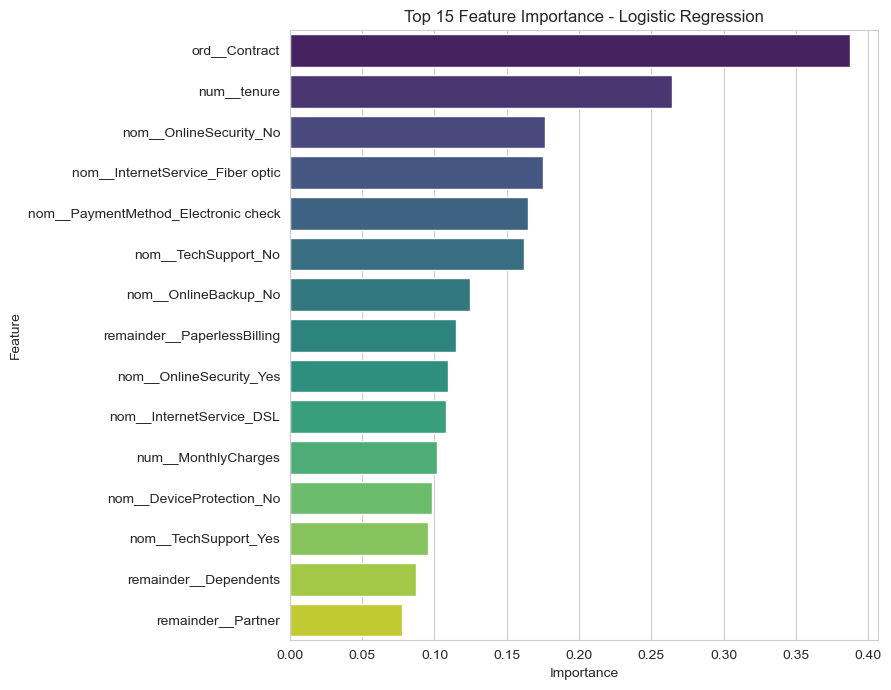

,Feature,Importance
2,ord__Contract,0.387393
0,num__tenure,0.263966
13,nom__OnlineSecurity_No,0.176343
4,nom__InternetService_Fiber optic,0.175105
8,nom__PaymentMethod_Electronic check,0.164695
22,nom__TechSupport_No,0.162225
16,nom__OnlineBackup_No,0.124663
36,remainder__PaperlessBilling,0.115192
15,nom__OnlineSecurity_Yes,0.109321
3,nom__InternetService_DSL,0.108083


In [249]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(9, 7))
    sns.barplot(x='Importance', y='Feature', data=fi_df, hue='Feature', palette='viridis', legend=False)
    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()
    display(fi_df)


**Insight:**

Fitur dengan importance tertinggi diharapkan konsisten dengan temuan EDA & uji inferensial (Bab 4). Umumnya kolom `Contract`, `tenure`, `InternetService_Fiber optic`, `MonthlyCharges`, dan `PaymentMethod_Electronic check` muncul sebagai driver utama.

## 7. Business Recommendation & Cost-Benefit Analysis

### 7.1 Kerangka Biaya: Fokus pada False Negative (FN) & False Positive (FP)

**Mengapa hanya FN & FP?** Dua kuadran inilah yang merepresentasikan **kesalahan** model, dan tiap kesalahan punya konsekuensi biaya berbeda:

| Error | Arti | Biaya (per pelanggan) |
|---|---|---|
| **FN** (pred No, aktual Yes) | Churner **terlewat**, tidak ditawari retensi | `1.0 × MonthlyCharges` → revenue 1 bulan **hilang penuh** |
| **FP** (pred Yes, aktual No) | Pelanggan loyal **salah ditawari** promo | `0.2 × MonthlyCharges` → biaya promo **sia-sia** (diskon 20%) |

Biaya bergantung pada `MonthlyCharges` tiap pelanggan (bukan flat). **FN jauh lebih mahal per pelanggan** (kehilangan seluruh revenue) dibanding FP (hanya buang sebagian biaya promo). Ini konsekuensi langsung dari pertimbangan di Bab 1.5, dan alasan metrik utama kita adalah **F2-Score** (mengutamakan recall/menekan FN).

Dua skenario dibandingkan pada **test set** (representasi populasi pelanggan aktual):
1. **Tanpa Model, Pendekatan Acak**: sesuai kondisi eksisting (Bab 1.1), seluruh pelanggan diberi penawaran retensi secara acak/blanket tanpa prediksi, sehingga setiap pelanggan dikenakan biaya promo `0.2 × MonthlyCharges`, termasuk pelanggan yang sebenarnya tidak akan churn.
2. **Dengan Model**: hanya pelanggan yang **diprediksi churn** (memakai threshold optimal Bab 6.6) yang diberi penawaran retensi. Kesalahan model dihitung sebagai FN (churner terlewat, revenue hilang penuh) dan FP (promo sia-sia ke pelanggan loyal).


### 7.2 Trade-off Biaya FN vs FP terhadap Threshold

**Threshold yang dipakai di sini SAMA dengan threshold operasional Bab 6.6 (F2-optimal).** Kita tidak memperkenalkan angka threshold baru, analisis biaya ini untuk melihat konsekuensi biaya dari threshold yang sudah dipilih pada skenario Dengan Model, serta memahami bagaimana biaya FN & FP bergerak jika threshold digeser.

Threshold menentukan trade-off antara dua error:
- Threshold **naik** (makin konservatif): model makin jarang menandai churn, **FN naik** (makin banyak churner terlewat, mahal) tapi **FP turun** (makin sedikit promo sia-sia).
- Threshold **turun** (makin agresif): **FN turun** (bagus) tapi **FP naik** (banyak pelanggan loyal ikut ditawari).

Karena **FN jauh lebih mahal per pelanggan** (Bab 7.1), F2-Score (dan threshold Bab 6.6) memang sengaja condong ke arah menekan FN, dan grafik di bawah memperlihatkan letak threshold tersebut pada kurva biaya.


In [250]:
# Parameter biaya FN & FP (horizon 1 bulan)
FP_DISCOUNT = 0.20   # biaya FP = 20% * MonthlyCharges (promo sia-sia ke pelanggan loyal)
HORIZON_MONTHS = 1   # selaras periode prediksi (Bab 1.4)

def cost_fn_fp(monthly_charges, y_true, y_pred, fp_rate=FP_DISCOUNT, horizon=HORIZON_MONTHS):
    '''Total biaya hanya dari FN & FP.
    FN = revenue 1 bulan hilang penuh; FP = biaya promo 20%. TP & TN tidak dihitung.'''
    m = np.asarray(monthly_charges) * horizon
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    fn = (y_pred == 0) & (y_true == 1)
    fp = (y_pred == 1) & (y_true == 0)
    cost_fn = m[fn].sum()             # revenue hilang penuh
    cost_fp = (fp_rate * m[fp]).sum() # biaya promo sia-sia
    return {'total': cost_fn + cost_fp, 'cost_fn': cost_fn, 'cost_fp': cost_fp,
            'n_fn': int(fn.sum()), 'n_fp': int(fp.sum())}
print("Fungsi biaya FN & FP siap (skenario Dengan Model, fokus 2 tipe error: FN & FP).")


Fungsi biaya FN & FP siap (skenario Dengan Model, fokus 2 tipe error: FN & FP).


In [251]:
# Gunakan threshold operasional yang SAMA dengan Bab 6.6 (F2-optimal) -- tidak ada threshold baru
operating_threshold = best_threshold   # dari Bab 6.6
mc_test = X_test['MonthlyCharges'].values
print(f"Threshold operasional (sama dgn Bab 6.6): {operating_threshold:.2f}")

Threshold operasional (sama dgn Bab 6.6): 0.35


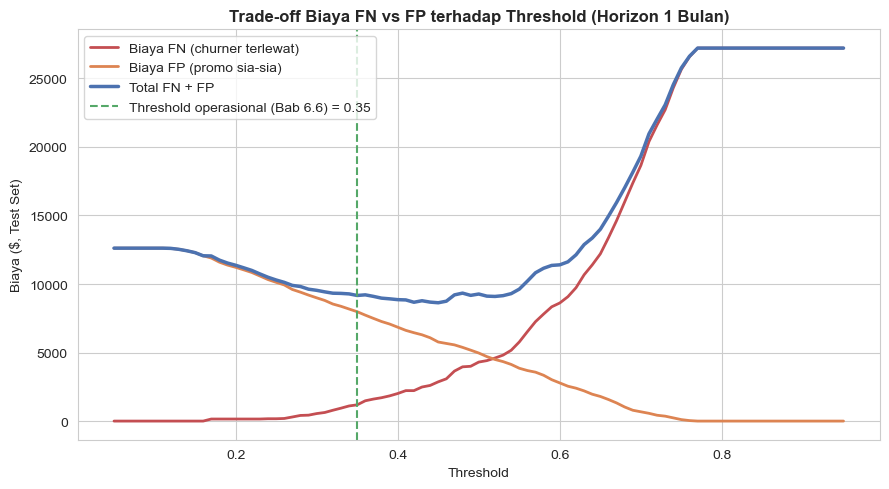

In [252]:
# Kurva biaya FN, FP, total vs threshold (dihitung pada TEST agar konsisten dgn Bab 6.6 & 7.3)
threshold_grid = np.arange(0.05, 0.96, 0.01)
fn_curve, fp_curve, total_curve = [], [], []
for t in threshold_grid:
    r = cost_fn_fp(mc_test, y_test.values, (y_proba_test >= t).astype(int))
    fn_curve.append(r['cost_fn']); fp_curve.append(r['cost_fp']); total_curve.append(r['total'])
fn_curve = np.array(fn_curve); fp_curve = np.array(fp_curve); total_curve = np.array(total_curve)

plt.figure(figsize=(9, 5))
plt.plot(threshold_grid, fn_curve, color='#C44E52', linewidth=2, label='Biaya FN (churner terlewat)')
plt.plot(threshold_grid, fp_curve, color='#DD8452', linewidth=2, label='Biaya FP (promo sia-sia)')
plt.plot(threshold_grid, total_curve, color='#4C72B0', linewidth=2.5, label='Total FN + FP')
plt.axvline(operating_threshold, color='#55A868', linestyle='--',
            label=f'Threshold operasional (Bab 6.6) = {operating_threshold:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Biaya ($, Test Set)')
plt.title('Trade-off Biaya FN vs FP terhadap Threshold (Horizon 1 Bulan)', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

**Insight (dibaca dari grafik):**
- Saat threshold **membesar** (ke kanan), kurva **FN (merah) menaik**, makin banyak churner terlewat. Sedangkan kurva **FP (oranye) menurun**, makin sedikit promo salah sasaran. Keduanya bergerak **berlawanan arah**, persis definisi trade-off.
- Kurva **FP berada jauh di atas FN** di hampir seluruh rentang threshold. Ini **bukan** karena FP lebih mahal per pelanggan (justru sebaliknya, FN ~4x lebih mahal per orang), melainkan karena **jumlah FP jauh lebih banyak** atau banyak pelanggan loyal ikut tertandai. Jadi secara **total Dollar**, FP mendominasi biaya.
- Kurva **total (biru)** relatif landai di sekitar threshold rendah-menengah, lalu menanjak di threshold tinggi (saat FN meledak). **Threshold operasional Bab 6.6 (garis hijau)** berada di area landai tersebut. Kombinasi yang wajar: menekan FN (prioritas bisnis) tanpa membuat total biaya melonjak.

### 7.3 Evaluasi Biaya FN & FP di Test Set

In [253]:
# Evaluasi biaya FN & FP pada threshold operasional (Bab 6.6) -- konsisten dgn confusion matrix Bab 6.6
y_pred_cost = (y_proba_test >= operating_threshold).astype(int)
res = cost_fn_fp(mc_test, y_test.values, y_pred_cost)

fnfp_table = pd.DataFrame({
    'Tipe Error': ['FN: Churner terlewat (revenue 1 bln hilang penuh)',
                   'FP: Promo sia-sia ke pelanggan loyal (diskon 20%)'],
    'Jumlah Pelanggan': [res['n_fn'], res['n_fp']],
    'Total Biaya ($)': [res['cost_fn'], res['cost_fp']],
})
fnfp_table['Biaya per Pelanggan ($)'] = (fnfp_table['Total Biaya ($)'] / fnfp_table['Jumlah Pelanggan'].replace(0,1)).round(1)
fnfp_table['% dari Total'] = (fnfp_table['Total Biaya ($)'] / res['total'] * 100).round(1)
print(f"Threshold operasional (Bab 6.6): {operating_threshold:.2f}  |  Total biaya FN+FP (test): ${res['total']:,.0f}")
display(fnfp_table)

Threshold operasional (Bab 6.6): 0.35  |  Total biaya FN+FP (test): $9,165


,Tipe Error,Jumlah Pelanggan,Total Biaya ($),Biaya per Pelanggan ($),% dari Total
0,FN: Churner terlewat (revenue 1 bln hilang penuh),19,1184.7,62.4,12.9
1,FP: Promo sia-sia ke pelanggan loyal (diskon 20%),558,7979.9,14.3,87.1


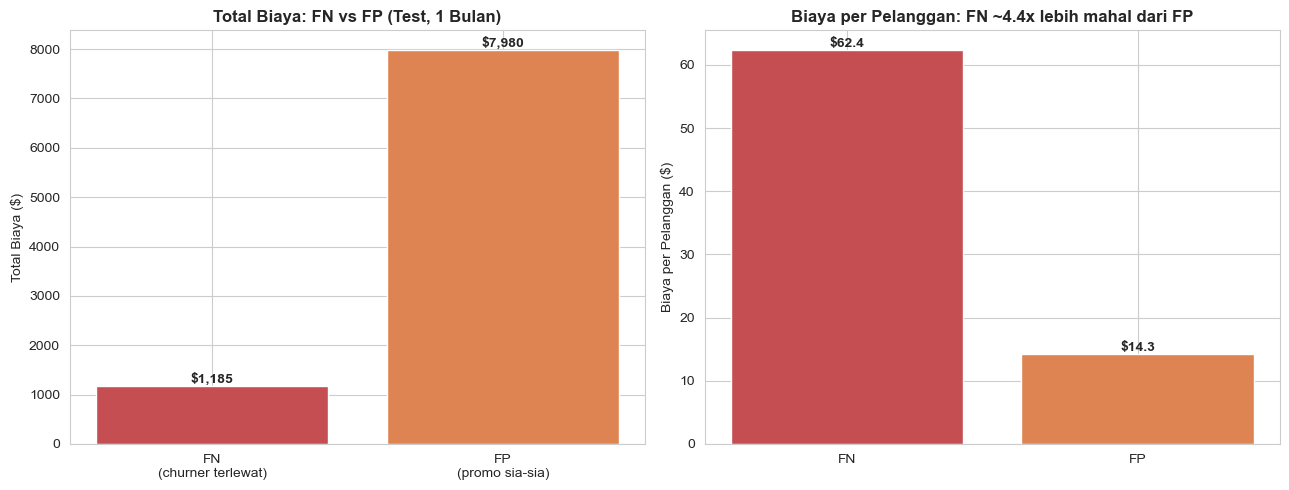

Biaya per pelanggan FN : $62.4  (revenue 1 bulan hilang penuh)
Biaya per pelanggan FP : $14.3  (hanya biaya promo 20%)


In [254]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (kiri) Total biaya FN vs FP
axes[0].bar(['FN\n(churner terlewat)', 'FP\n(promo sia-sia)'],
            [res['cost_fn'], res['cost_fp']], color=['#C44E52', '#DD8452'])
for i, v in enumerate([res['cost_fn'], res['cost_fp']]):
    axes[0].text(i, v, f"${v:,.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Total Biaya: FN vs FP (Test, 1 Bulan)', fontweight='bold')
axes[0].set_ylabel('Total Biaya ($)')

# (kanan) Biaya per pelanggan FN vs FP
per_fn = res['cost_fn']/max(res['n_fn'],1)
per_fp = res['cost_fp']/max(res['n_fp'],1)
axes[1].bar(['FN', 'FP'], [per_fn, per_fp], color=['#C44E52', '#DD8452'])
for i, v in enumerate([per_fn, per_fp]):
    axes[1].text(i, v, f"${v:,.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title(f'Biaya per Pelanggan: FN ~{per_fn/max(per_fp,1e-9):.1f}x lebih mahal dari FP', fontweight='bold')
axes[1].set_ylabel('Biaya per Pelanggan ($)')

plt.tight_layout(); plt.show()

print(f"Biaya per pelanggan FN : ${per_fn:,.1f}  (revenue 1 bulan hilang penuh)")
print(f"Biaya per pelanggan FP : ${per_fp:,.1f}  (hanya biaya promo 20%)")

**Insight (Fokus FN vs FP, Skenario Dengan Model):**
- **Per pelanggan**, FN jauh lebih mahal (kurang lebih 4-5x) dibanding FP, karena FN berarti kehilangan seluruh revenue sedangkan FP hanya membuang sebagian biaya promo. Ini menjustifikasi pemakaian **F2-Score** & threshold operasional (Bab 6.6) yang cenderung rendah (mengutamakan menekan FN).
- **Secara total**, biaya FP bisa jadi lebih besar dibanding FN jika jumlah FP jauh lebih banyak (banyak pelanggan loyal ikut ditandai), konsisten dengan grafik trade-off di Bab 7.2 dimana kurva FP cenderung berada di atas FN pada threshold rendah-menengah.
- **Implikasi operasional:** untuk menekan biaya FP tanpa menaikkan FN berlebihan, retensi sebaiknya diarahkan lewat **Risk Tier** (Bab 6.7), penawaran agresif hanya untuk **High Risk**, sementara Medium Risk cukup nudge ringan berbiaya rendah. Dengan begitu, biaya FP (yang banyak berasal dari salah-tembak) dapat ditekan tanpa mengorbankan penangkapan churner.


### 7.4 Perbandingan Skenario: Dengan Model vs Tanpa Model (Pendekatan Acak)

Bab 7.1-7.3 menghitung biaya kesalahan (FN & FP) untuk skenario **Dengan Model**. Untuk menjawab Problem Statement #3 (Bab 1.3), yaitu seberapa besar model membantu **mengurangi biaya churn dibanding pendekatan tanpa model**, kita bandingkan totalnya dengan skenario **Tanpa Model, Pendekatan Acak** (kondisi eksisting di Bab 1.1: seluruh pelanggan ditawari promo retensi tanpa prediksi).

**Asumsi skenario Tanpa Model (Pendekatan Acak):** karena seluruh pelanggan diberi penawaran retensi, diasumsikan tidak ada pelanggan yang "terlewat" (tidak ada FN), sehingga biaya yang timbul hanya biaya diskon (`0.2 x MonthlyCharges`) untuk **seluruh** pelanggan di test set. Ini asumsi optimistis (retensi dianggap 100% efektif) yang membuat perbandingan ini menjadi **batas bawah** potensi penghematan, bukan angka pasti; lihat catatan limitasi di Bab 7.5.


In [255]:
# Skenario Tanpa Model, Pendekatan Acak (Blanket Retention / kondisi eksisting Bab 1.1)
def cost_random_approach(monthly_charges, fp_rate=FP_DISCOUNT, horizon=HORIZON_MONTHS):
    '''Biaya skenario Tanpa Model, Pendekatan Acak.
    Seluruh pelanggan ditawari retensi (diskon) tanpa prediksi.
    Asumsi: seluruh pelanggan yang ditawari retensi tidak jadi churn,
    sehingga tidak ada revenue hilang (FN); biaya hanya dari diskon promo
    untuk seluruh pelanggan.'''
    m = np.asarray(monthly_charges) * horizon
    return {'total': (fp_rate * m).sum(), 'n_offered': len(m)}

res_random = cost_random_approach(mc_test)
n_offered_model = int((y_pred_cost == 1).sum())

scenario_table = pd.DataFrame({
    'Skenario': ['Tanpa Model (Pendekatan Acak)', 'Dengan Model'],
    'Jumlah Pelanggan Ditawari Promo': [res_random['n_offered'], n_offered_model],
    'Total Biaya ($)': [res_random['total'], res['total']],
})
scenario_table['Penghematan vs Pendekatan Acak ($)'] = scenario_table['Total Biaya ($)'].iloc[0] - scenario_table['Total Biaya ($)']
scenario_table['Penghematan (%)'] = (scenario_table['Penghematan vs Pendekatan Acak ($)'] / scenario_table['Total Biaya ($)'].iloc[0] * 100).round(1)

print(f"Total biaya Tanpa Model (Pendekatan Acak): ${res_random['total']:,.0f}  |  seluruh {res_random['n_offered']} pelanggan ditawari promo")
print(f"Total biaya Dengan Model                  : ${res['total']:,.0f}  |  hanya {n_offered_model} pelanggan ditawari promo")
display(scenario_table)


Total biaya Tanpa Model (Pendekatan Acak): $18,060  |  seluruh 1409 pelanggan ditawari promo
Total biaya Dengan Model                  : $9,165  |  hanya 913 pelanggan ditawari promo


,Skenario,Jumlah Pelanggan Ditawari Promo,Total Biaya ($),Penghematan vs Pendekatan Acak ($),Penghematan (%)
0,Tanpa Model (Pendekatan Acak),1409,18060.24,0.00,0.0
1,Dengan Model,913,9164.60,8895.64,49.3


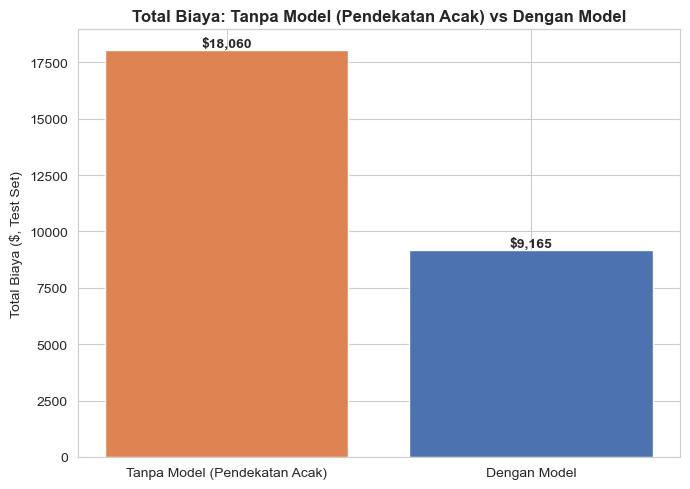

In [256]:
plt.figure(figsize=(7, 5))
bars = plt.bar(scenario_table['Skenario'], scenario_table['Total Biaya ($)'],
               color=['#DD8452', '#4C72B0'])
for b, v in zip(bars, scenario_table['Total Biaya ($)']):
    plt.text(b.get_x() + b.get_width()/2, v, f"${v:,.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylabel('Total Biaya ($, Test Set)')
plt.title('Total Biaya: Tanpa Model (Pendekatan Acak) vs Dengan Model', fontweight='bold')
plt.tight_layout(); plt.show()


**Insight:**
- Skenario **Dengan Model** menawarkan promo ke jauh lebih sedikit pelanggan dibanding pendekatan acak, karena hanya pelanggan yang diprediksi berisiko churn yang ditargetkan. Ini konsisten dengan tujuan bisnis di Bab 1.2, yaitu mengalokasikan budget retensi secara efisien (bukan blanket promotion).
- Selisih biaya pada tabel di atas adalah estimasi **batas atas penghematan**, dengan asumsi retensi acak 100% efektif mencegah churn. Pada praktiknya, efektivitas promo retensi tidak selalu 100%, sehingga skenario Tanpa Model kemungkinan tetap kehilangan sebagian revenue meski sudah menawarkan promo ke semua pelanggan; artinya penghematan riil bisa berbeda dari angka ini dan perlu dikalibrasi dengan data historis kampanye retensi perusahaan (lihat Bab 7.5 dan Rekomendasi Bab 7.6).


### 7.5 Kesimpulan

**Ringkasan model:** Model terbaik yang dipilih adalah **Logistic Regression** hasil tuning (Bab 6.4-6.6), dipilih bukan semata dari skor F2 tertinggi saat benchmarking, melainkan kombinasi performa yang kompetitif dan interpretability tinggi yang relevan bagi kebutuhan Tim Retensi dalam memahami driver churn (Bab 6.3).

**Menjawab Problem Statement (Bab 1.3):**
1. *Siapa yang berisiko churn?* Berdasarkan EDA (Bab 4) dan Risk Tier (Bab 6.7), segmen berisiko tertinggi adalah pelanggan dengan kontrak **Month-to-month**, **tenure rendah (kurang dari 10 bulan)**, pengguna layanan **Fiber optic**, dan metode pembayaran **Electronic check**.
2. *Faktor apa yang paling mendorong churn?* Feature importance (Bab 6.8) beserta uji statistik di Bab 4 mengonfirmasi bahwa `Contract`, `tenure`, `InternetService_Fiber optic`, `MonthlyCharges`, dan `PaymentMethod_Electronic check` adalah driver utama churn.
3. *Apakah model mengurangi biaya churn dibanding pendekatan tanpa model?* Ya. Perbandingan skenario di Bab 7.4 menunjukkan pendekatan Dengan Model menawarkan promo ke jauh lebih sedikit pelanggan dibanding pendekatan acak, dengan estimasi penghematan biaya seperti pada tabel Bab 7.4 (dengan catatan asumsi pada bab tersebut).

**Limitasi:**
- Model memprediksi risiko churn untuk horizon **1 bulan ke depan** (Bab 1.4), belum mencerminkan potensi kehilangan Customer Lifetime Value (CLV) jangka panjang dari pelanggan yang benar-benar churn.
- Asumsi biaya (`FP_DISCOUNT` = 20%, efektivitas retensi 100% pada skenario Tanpa Model di Bab 7.4) masih berupa asumsi awal, belum dikalibrasi dengan data historis kampanye retensi riil perusahaan.
- Evaluasi biaya dilakukan pada satu kali split test set (snapshot), belum ada validasi terhadap potensi *model drift* seiring waktu.

Poin-poin limitasi di atas menjadi dasar rekomendasi kalibrasi ulang dan re-evaluasi berkala pada Bab 7.6.


### 7.6 Rekomendasi Bisnis

Rekomendasi berikut ditujukan khusus untuk **Tim/Manajer Retensi Pelanggan** (stakeholder utama, Bab 1.6):

1. **Operasionalkan scoring bulanan + Risk Tier** (Bab 6.7): jalankan model setiap akhir periode billing untuk men-score seluruh pelanggan aktif, kelompokkan ke **Low/Medium/High Risk**, lalu bedakan intensitas penawaran, High Risk mendapat penawaran paling agresif, Medium Risk cukup nudge ringan (email/SMS), Low Risk tidak perlu aksi. Sesuai insight Bab 7.3, ini cara paling efektif menekan biaya FP (promo sia-sia) tanpa menaikkan FN.
2. **Gunakan threshold operasional dari Bab 6.6** sebagai titik operasi model. Analisis biaya (Bab 7.2-7.4) mengonfirmasi threshold ini berada di area biaya total yang wajar sambil tetap menekan FN, error yang lebih mahal per pelanggan.
3. **Fokuskan retensi proaktif** pada segmen risiko tertinggi dari EDA & feature importance (Bab 4 & 6.8): pelanggan **Month-to-month**, **tenure rendah (kurang dari 10 bulan)**, **Fiber optic**, dan pengguna **Electronic check**.
4. **Dorong migrasi ke kontrak tahunan/dua tahunan** sebagai lever retensi struktural, bukan sekadar insentif harga: pelanggan Month-to-month punya switching cost sangat rendah, sedangkan kontrak jangka panjang menaikkan komitmen secara kontraktual. Ini lever dengan dampak terbesar berdasarkan analisis statistik (Bab 4.3.2 & 4.5).
5. **Perbaiki akar masalah non-harga**: review kualitas/harga layanan **Fiber optic** dan dorong migrasi dari **Electronic check** ke metode auto-pay untuk mengurangi friksi yang berkontribusi pada churn, solusi struktural yang menurunkan churn tanpa terus-menerus mengeluarkan biaya promo.
6. **Kalibrasi ulang asumsi biaya dengan data riil**: ganti asumsi `FP_DISCOUNT` (20%) dan asumsi efektivitas retensi pada skenario Tanpa Model (Bab 7.4) dengan data historis kampanye retensi aktual perusahaan, lalu pilih ulang threshold penyeimbang bila perlu.
7. **Re-evaluasi model, threshold, & risk tier secara periodik** (misal tiap kuartal) menggunakan data terbaru, untuk mengantisipasi *model drift* dan menjaga relevansi asumsi biaya terhadap perilaku pelanggan yang berubah.
